# AFM Simulation and Regression Model


**This notebook provides a complete example on how to create a simulated AFM dataset and how to train a regression model for post-processing.**

The first section simulates a dataset while the second section builds and trains a model. Finally, the user can test the model on their experimental data. The notebook provides two final **Output**; **1:** A simulated AFM dataset, **2:** A trained model ready to process experimental data.

## 1. Optional installations

Uncomment the lines if using Colab/Kaggle.

In [1]:
#!pip3 install deeplay plotly ipywidgets ipympl

# from google.colab import output
# output.enable_custom_widget_manager()

## 2. Imports and configuration

Here we import necessary libraries and scripts.

In [2]:
from __future__ import annotations

import glob
import importlib
import json
import logging
import os
import random
import sys
from copy import deepcopy
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Optional

import matplotlib
import matplotlib.animation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import torch
import torch.nn as nn
from IPython.display import display
from matplotlib.pylab import maximum
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

import deeplay as dl
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger

torch.set_num_threads(1)

We configure our simulator and model. The user must configure the experimental parameters, sample parameters and if desired the model parameters to adapt to their experimental setup.

1. **SimulationConfig**:
    1. The user must select the scan resolution that consists of pixel number $(n_x, n_y)$ and pixel size.
    2. Force-distance curve (FDC) parameters must be defined: $z~length$, $z~speed$, sampling frequency $f_s$ and $set-point~force$.
    3. Depending on the cantilever choice the tip shape and the desired thermal noise type must be selected.
    4. Curve mode must be selected between 'approach' and 'approach-retract'. This will depend on the used contact mechanics model.
3. **DatasetConfig**:
    1. Quantity of samples for training, validating and testing must be indicated.
    2. Topography types we want to use and the height range we are expecting.
    3. Range of stiffness for the substrate and the sample must be indicated. This is only an estimation and doesn't need to be precise.
5. **ModelConfig**:
    1. This contains the parameters of the model. The user does not need to adjust these values but it can b emodified if desired.

In [3]:
SEED = 69
np.random.seed(SEED)
torch.manual_seed(SEED)

@dataclass
class SimulationConfig:
    """Configuration for AFM simulation parameters."""

    nx = 16
    ny = 16
    pixel_size_m = 2e-6
    z_length_m = 3e-6
    z_speed_um_s = 9
    sampling_frequency_hz = 3000
    setpoint_force_n_range = [1e-9, 1e-9]
    tip_shape = "Sphere"  # options: "Pyramid", "Sphere"
    include_thermal_noise = True
    noise_type = "experimental"  # options: "theoretical", "experimental", "rms"
    experimental_noise_path = \
      "./thermal-noise-data_vDeflection_2025.11.28-16.42.57.tnd"
    curve_mode = "approach"  # options: "approach", "approach_retract"
    artefact = False # options: True, False
    range_artefact = "short" # options: "short", "long"

@dataclass
class DatasetConfig:
    """Configuration for dataset generation parameters."""

    n_samples =40
    topography_types = ("gaussian_features", "hemisphere")
    substrate_stiffness_range_pa = (0.1e3, 5e3)
    feature_stiffness_range_pa = (0.1e3, 5e3)
    height_range_m = (0.5e-7, 2.9e-6)

@dataclass
class ModelConfig:
    """Configuration for model training parameters."""

    batch_size = 4096
    learning_rate = 2e-3
    max_epochs = 1000
    predict_contact_point = True
    cp_loss_weight = 0.5
    num_workers = 0
    accelerator = "auto"
    devices = 1
    default_sample_to_display = 0


simulation_config = SimulationConfig()
dataset_config = DatasetConfig()
model_config = ModelConfig()

print(simulation_config)
print(dataset_config)
print(model_config)


SimulationConfig()
DatasetConfig()
ModelConfig()


## 3. Cantilever model with PSD


The `AFMCantilever` class represents the physical cantilever. Required inputs are: tip geometry, tip size, spring constant, resonance frequency, quality factor, and temperature — all available on the cantilever box or thermal calibration file.

The class handles two responsibilities: computing the contact area for a given indentation, and generating thermal noise. Three noise options are provided:

1. **Equipartition theorem**: The mean square displacement of the cantilever under thermal fluctuations is equal to $ k_B T / k $ under the equipartitoin theorem. In order to use this option the spring constant of the cantilever and the temperature we operate in must be known. Select 'rms' for the noise type.
   
2. **Theoretical PSD**: The cantilever behaves as a damped harmonic oscillator for which we can compute the power spectral density (PSD) that we denote as $S(f_x, f_y)$. Depending on our sampling frequency we compute a time domain noise from the theoretical PSD. Alongside the spring constant of the cantilever and the temperature, the user must also input the resonant frequency and the quality factor of the cantilever. Select 'Theoretical' for the noise type.
   
3. **Experimental PSD**: In the beginning of an AFM experiment the software measures the PSD of the cantilever in order to do thermal calibration. In this option the time domain noise is generated from the experimental PSD. Select 'Experimental' for the noise type and provide the path that leads to the '.tnd' calibration file.

In [4]:
class AFMCantilever:
    """AFM cantilever model with thermal-noise PSD support.

    This class represents the cantilever and stores parameters relevant to its
    thermal noise characteristics, allowing for both theoretical and
    experimental PSDs to be used in simulations.

    Parameters
    ----------
    k: float
        Spring constant in N/m.
    f0: float
        Resonance frequency in Hz.
    Q: float
        Quality factor.
    T: float
        Temperature in kelvin.

    Methods
    -------
    `thermal_noise_rms() -> float`
        Returns the RMS thermal deflection in meters.
    `thermal_noise_psd_theoretical(frequency_hz) -> np.ndarray`
        Returns the one-sided theoretical displacement PSD in m^2/Hz.
    `thermal_noise_psd_experimental(path) -> tuple[np.ndarray, np.ndarray, np.ndarray]`
        Loads and caches an experimental displacement PSD from a file.
    `get_noise_psd(...) -> tuple[np.ndarray, np.ndarray]`
        Returns the simulation-grid PSD based on the specified noise type.
    `sample_thermal_noise(...) -> np.ndarray`
        Draws one thermal-noise trace from the PSD and returns it in meters.

    """

    def __init__(
        self: AFMCantilever,
        k: float =0.1,
        f0: float =7e3,
        Q: float =10.0,
        T: float =300.0,
    ):
        """Initializes the AFMCantilever.

        Initializes the AFMCantilever with given parameters and computes
        derived properties.

        Parameters
        ----------
        k: float, optional
            Spring constant in N/m (default is 0.1).
        f0: float, optional
            Resonance frequency in Hz (default is 7e3).
        Q: float, optional
            Quality factor (default is 10.0).
        T: float, optional
            Temperature in kelvin (default is 300.0).

        """

        self.k = k
        self.f0 = f0
        self.Q = Q
        self.T = T
        self.kB = 1.380649e-23
        self.m_eff = k / (2.0 * np.pi * f0) ** 2
        self.gamma = 2.0 * np.pi * f0 * self.m_eff / Q
        self._experimental_psd_cache = {}
        self._grid_psd_cache = {}

    def thermal_noise_rms(
        self: AFMCantilever,
    ) -> float:
        """Return the RMS thermal deflection in meters.

        Returns
        -------
        float
            RMS thermal deflection in meters.

        """

        return np.sqrt(self.kB * self.T / self.k)

    def thermal_noise_psd_theoretical(
        self: AFMCantilever,
        frequency_hz: np.ndarray,
    ) -> np.ndarray:
        """Return the one-sided theoretical displacement PSD.

        Parameters
        ----------
        frequency_hz: np.ndarray
                Frequencies in Hz at which to evaluate the PSD.

        Returns
        -------
        np.ndarray
            PSD in m^2/Hz.

        """

        omega  = 2.0 * np.pi * frequency_hz
        omega0 = 2.0 * np.pi * self.f0
        denom  = (omega0**2 - omega**2)**2 + (omega * omega0 / self.Q)**2
        return (4.0 * self.kB * self.T * self.gamma) / (self.k**2 * denom)

    def thermal_noise_psd_experimental(
        self: AFMCantilever,
        path: str,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Load and cache an experimental displacement PSD.

        Loads the experimental PSD from the provided path. Converts the
        displacement from volts to meters using the metadata in the file.

        Parameters
        ----------
        path: str
            Path to the experimental PSD file.

        Returns
        -------
        tuple of np.ndarray
            (frequency_hz, spectral_density_x, spectral_density_x_fit)

        """

        cache_key = str(path)
        if cache_key not in self._experimental_psd_cache:
            data = np.loadtxt(path, skiprows=24)
            frequency_hz       = data[:, 0]
            spectral_density_v = data[:, 1]
            spectral_density_v_fit = data[:, 3]
            with open(path, "r") as f:
                lines = f.readlines()
            for line in lines:
                if "sensitivity" in line:
                    volts_to_displacement_nm = \
                      float(line.split(":")[1].split()[0])
                if "parameter.f" in line:
                    self.f0 = float(line.split(":")[1].split()[0]) * 1e3
                if "parameter.Q" in line:
                    self.Q = float(line.split(":")[1].split()[0])
            scale = volts_to_displacement_nm * 1e-9
            self._experimental_psd_cache[cache_key] = (
                frequency_hz,
                spectral_density_v     * scale**2,
                spectral_density_v_fit * scale**2,
            )
        return self._experimental_psd_cache[cache_key]

    def get_noise_psd(
        self: AFMCantilever,
        n_points: int,
        sampling_frequency_hz: float,
        noise_type: str = simulation_config.noise_type,
        experimental_path: str = simulation_config.experimental_noise_path,
    ) -> tuple[np.ndarray, np.ndarray]:
        """Returns the simulation-grid PSD.

        Returns the theoretical PSD calculated with the harmonic oscillator
        model. When it's possible the cached results are reused.

        Parameters
        ----------
        n_points: int
            Number of points in the simulation grid.
        sampling_frequency_hz: float
            Sampling frequency in Hz.
        noise_type: str
            Type of noise ("theoretical", "experimental" or "rms").
        experimental_path: str or None
            Path to the experimental PSD file.

        Returns
        -------
        tuple of np.ndarray
            (frequency_hz, spectral_density_x)

        """

        cache_key = (noise_type.lower(), int(n_points), \
                     float(sampling_frequency_hz),None if experimental_path
                     is None else str(experimental_path))
        if cache_key in self._grid_psd_cache:
            return self._grid_psd_cache[cache_key]

        frequency_hz = np.fft.rfftfreq(n_points, d=1.0 / sampling_frequency_hz)
        if noise_type.lower() == "theoretical":
            spectral_density_x = \
              self.thermal_noise_psd_theoretical(frequency_hz)
        elif noise_type.lower() == "experimental":
            if experimental_path is None:
                raise ValueError("`experimental_path` must be provided for \
                experimental PSD.")
            frequency_hz, spectral_density_x, _ = (
                self.thermal_noise_psd_experimental(experimental_path)
            )
        else:
            raise ValueError(f"Unknown noise type: {noise_type}")

        self._grid_psd_cache[cache_key] = (frequency_hz, spectral_density_x)
        return self._grid_psd_cache[cache_key]

    def sample_thermal_noise(
        self: AFMCantilever,
        n_points: int,
        sampling_frequency_hz: float,
        noise_type: str = simulation_config.noise_type,
        experimental_path: str = simulation_config.experimental_noise_path,
        rng=None,
    ) -> np.ndarray:
        """Draws one thermal-noise trace from the PSD.

        Draws one trace of thermal noise from the PSD using random phase and
        converts it to time domain noise using np.fft.irfft

        Parameters
        ----------
        n_points: int
            Number of points in the simulation grid.
        sampling_frequency_hz: float
            Sampling frequency in Hz.
        noise_type: str
            Type of noise ("theoretical", "experimental" or "rms").
        experimental_path: str or None
            Path to the experimental PSD file.
        rng: numpy.random.Generator or None
            Random number generator instance. If None, a new instance is
            created.

        Returns
        -------
        np.ndarray
            Noise trace in meters, shape (n_points,).

        """

        rng = np.random.default_rng() if rng is None else rng
        frequency_hz, spectral_density_x = self.get_noise_psd(
            n_points, sampling_frequency_hz, noise_type, experimental_path
        )
        df = sampling_frequency_hz / n_points

        amplitude = n_points * \
                            np.sqrt(np.maximum(spectral_density_x * df/2, 0.0))
        coefficients = np.zeros(amplitude.shape[0], dtype=np.complex128)

        if amplitude.shape[0] > 2:
            phase = rng.uniform(0.0, 2.0 * np.pi, size=amplitude.shape[0] - 2)
            coefficients[1:-1] = amplitude[1:-1] * np.exp(1j * phase)
        coefficients[0] = 0.0
        if n_points % 2 == 0 and amplitude.shape[0] > 1:
            coefficients[-1] = amplitude[-1] * np.sign(rng.standard_normal())

        noise_m = np.fft.irfft(coefficients, n=n_points).real
        rms      = self.thermal_noise_rms()
        std      = np.std(noise_m)
        # Guard against zero std.
        if std > 0:
            noise_m = noise_m / std * rms
        else:
            noise_m = rng.normal(scale=rms, size=n_points)
        return noise_m


**Thermal noise from file**

Uncomment and run this cell if you wish to load an experimental thermal calibration file. When running locally, store the file in the folder with the script and make sure that the path is accessible.

In [5]:
# from google.colab import files
# import os

# print("Upload your experimental PSD text file (e.g., .txt or .csv):")
# uploaded = files.upload()
# for filename in uploaded.keys():
#      print(f'Uploaded "{filename}" ({len(uploaded[filename])} bytes)')
#      simulation_config.experimental_noise_path = filename
#      simulation_config.noise_type = "Experimental"


## 4. Contact mechanics


The `HertzContact` class transforms indentation depth into a force response. The Hertz model is provided as an example suited to biological applications. You can replace it with any contact model appropriate for your experiment.

In [6]:
class HertzContact:
    """Hertz contact model for spherical and pyramidal tips.

    Represents the relationship between indentation and force. Stores
    information related to contact geometry and contact mechanics.

    Parameters
    ----------
    R: float
        Tip radius in meters.
    nu: float
        Poisson ratio of the sample.
    alpha: float
        Pyramid face angle in degrees.

    Methods
    -------
    `alpha_rad() -> float`
        Returns the pyramid face angle in radians.
    `hertz_sphere(indentation_m, stiffness_pa) -> float`
        Returns the Hertz force for a spherical tip.
    `hertz_cone(indentation_m, stiffness_pa) -> float`
        Returns the Hertz-like force for a conical approximation.
    `force(...) -> float`
        Returns the contact force for the given indentation, supporting 
        optional two-stiffness (bi-layer) mode.

    """

    def __init__(
        self: HertzContact,
        R: float = 10e-9,
        nu: float = 0.5,
        alpha: float = 18.0,
    ):
        """Initializes the HertzContact model.

        Initializes the HertzContact model with given parameters.

        Parameters
        ----------
        R: float
            Tip radius in meters.
        nu: float
            Poisson ratio of the sample.
        alpha: float
            Pyramid face angle in degrees.

        """

        self.R = R
        self.nu = nu
        self.alpha = alpha

    @property
    def alpha_rad(
        self: HertzContact,
    ) -> float:
        """Return the pyramid face angle in radians.

        Returns
        -------
        float
            Pyramid face angle in radians.

        """

        return np.deg2rad(self.alpha)

    def hertz_sphere(
        self: HertzContact,
        indentation_m: float,
        stiffness_pa: float,
    ) -> float:
        """Return the Hertz force for a spherical tip.

        Returns the force response of a purely elastic semi finite substrate
        with the given stiffness in response to given indentation depth for a
        spherical indentor.

        Parameters
        ----------
        indentation_m: float
            Indentation depth in meters.
        stiffness_pa: float
            Young's modulus in pascal.

        Returns
        -------
        float
            Contact force in newtons.

        """

        return (
            (4.0 / 3.0)
            * stiffness_pa
            * np.sqrt(self.R)
            * indentation_m**1.5
            / (1.0 - self.nu**2)
        )

    def hertz_cone(
        self: HertzContact,
        indentation_m: float,
        stiffness_pa: float,
    ) -> float:
        """Return the Hertz-like force for a conical approximation.

        Returns the force response of a purely elastic semi finite substrate
        with the given stiffness in response to given indentation depth for a
        conical indentor.

        Parameters
        ----------
        indentation_m: float
            Indentation depth in meters.
        stiffness_pa: float
            Young's modulus in pascal.

        Returns
        -------
        float
            Contact force in newtons.

        """

        return (
            stiffness_pa
            * np.tan(self.alpha_rad)
            * indentation_m**2
            / (np.sqrt(2.0) * (1.0 - self.nu**2))
        )

    def force(
        self: HertzContact,
        cantilever_shape: str,
        indentation_m: float,
        stiffness_pa: float,
        stiffness_2_pa: float = None,
        transition_depth_m: float = None,
    ) -> float:
        """Return the contact force for the given indentation.

        Supports an optional two-stiffness (bi-layer) mode.  When both
        ``stiffness_2_pa`` and ``transition_depth_m`` are provided, the model
        uses ``stiffness_pa`` (E1) for the surface layer and
        ``stiffness_2_pa`` (E2) for any additional indentation beyond
        ``transition_depth_m``.  The force is continuous at the transition:

            F(δ) = Hertz(min(δ, δ_t), E1) + Hertz(max(0, δ − δ_t), E2)

        Parameters
        ----------
        cantilever_shape: str
            Tip geometry, either ``'Sphere'`` or ``'Pyramid'``.
        indentation_m: float
            Indentation depth in meters.
        stiffness_pa: float
            Young's modulus of the first (surface) layer in pascal.
        stiffness_2_pa: float or None, optional
            Young's modulus of the second (stiffer) layer in pascal.
            Bi-layer mode is activated only when both this and
            ``transition_depth_m`` are not None.
        transition_depth_m: float or None, optional
            Indentation depth at which the tip reaches the second layer [m].

        Returns
        -------
        float
            Contact force in newtons.

        """

        indent = np.maximum(np.asarray(indentation_m, dtype=np.float64), 0.0)

        if stiffness_2_pa is not None and transition_depth_m is not None:
            t  = np.asarray(transition_depth_m, dtype=np.float64)
            E2 = np.asarray(stiffness_2_pa,     dtype=np.float64)
            below = np.minimum(indent, t)        # indentation absorbed by layer 1
            extra = np.maximum(indent - t, 0.0) # extra indentation into layer 2
            if cantilever_shape == "Sphere":
                return self.hertz_sphere(below, stiffness_pa) +\
                 self.hertz_sphere(extra, E2)
            if cantilever_shape == "Pyramid":
                return self.hertz_cone(below, stiffness_pa) +\
                 self.hertz_cone(extra, E2)
            raise ValueError(f"Unsupported cantilever shape: \
            {cantilever_shape}")

        if cantilever_shape == "Sphere":
            return self.hertz_sphere(indent, stiffness_pa)
        if cantilever_shape == "Pyramid":
            return self.hertz_cone(indent, stiffness_pa)
        raise ValueError(f"Unsupported cantilever shape: {cantilever_shape}")


## 5. Synthetic sample-map generator


The `SampleGenerator` class builds a synthetic sample. You provide topography type and mechanical property ranges; the class returns a 2D topography map, a stiffness map, and a **contact point map**.

### Contact point convention

The contact point is defined as the **absolute z-position along the displacement axis** at which the tip first touches the sample surface. A large contact-point value means the tip is still far from the surface when first contact occurs (i.e., the approach has barely started). A small value means the tip nearly traverses the full scan range before touching.




In [7]:
class SampleGenerator:
    """Generate topography, stiffness, and contact-point maps.

    Generates synthetic sample maps with specified topography types, stiffness
    ranges, and contact point ranges.

    Parameters
    ----------
    substrate_stiffness_range_pa: tuple
        Range of substrate stiffness in pascal (min, max).
    feature_stiffness_range_pa: tuple
        Range of feature stiffness in pascal (min, max).
    height_range_m: tuple
        Range of feature heights in meters (min, max).

    Methods
    -------
    `create_topography(size, pixel_size_m, topography_type) -> tuple[np.ndarray]`
        Creates synthetic topography and stiffness maps based on the specified
        parameters.

    """

    def __init__(
        self: SampleGenerator,
        substrate_stiffness_range_pa: tuple = (5e3, 10e3),
        feature_stiffness_range_pa: tuple = (2e3, 5e3),
        height_range_m: tuple = (1e-6, 4e-6),
    ):
        """Initializes the SampleGenerator with specified parameters.

        Initializes the SampleGenerator with given stiffness ranges, height
        ranges, and contact point ranges.

        Parameters
        ----------
        substrate_stiffness_range_pa: tuple
            Range of substrate stiffness in pascal (min, max).
        feature_stiffness_range_pa: tuple
            Range of feature stiffness in pascal (min, max).
        height_range_m: tuple
            Range of feature heights in meters (min, max).

        """

        self.substrate_stiffness_range_pa = substrate_stiffness_range_pa
        self.feature_stiffness_range_pa = feature_stiffness_range_pa
        self.height_range_m = height_range_m

    def create_topography(
        self: SampleGenerator,
        size: tuple = (128, 128),
        pixel_size_m: float = 1e-6,
        topography_type: str = "gaussian_features",
        rng=None,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Create one synthetic sample map.

        Parameters
        ----------
        size: tuple
            Map dimensions as ``(ny, nx)`` in pixels.
        pixel_size_m: float
            Physical size of one pixel in meters.
        topography_type: str
            ``'gaussian_features'`` or ``'hemisphere'``.
        rng: Optional[numpy.random.Generator]
            Optional numpy random generator.

        Returns
        -------
        tuple[np.ndarray, np.ndarray]
            Tuple of ``(topography_m, stiffness_map_pa)``.

        """

        rng = np.random.default_rng() if rng is None else rng

        ny, nx = size

        if nx==1 and ny==1:
            height_range_min, height_range_max = self.height_range_m
            topography_m = np.array([[rng.uniform(height_range_min, height_range_max)]])
            stiffness_map_pa = np.array([[rng.uniform(
                self.feature_stiffness_range_pa[0],
                self.feature_stiffness_range_pa[1],
            )]])

            return topography_m, stiffness_map_pa  
        
        topography_m = np.zeros((ny, nx), dtype=np.float64)
        stiffness_map_pa = rng.uniform(
            self.substrate_stiffness_range_pa[0],
            self.substrate_stiffness_range_pa[1],
            size=(ny, nx),
        )

        if topography_type == "gaussian_features":
            n_features = int(rng.integers(8, 12))
            y, x = np.ogrid[0:ny, 0:nx]
            for _ in range(n_features):
                cx = int(rng.integers(0, nx))
                cy = int(rng.integers(0, ny))
                amplitude = float(rng.uniform(*self.height_range_m))
                sigma_px = float(rng.uniform(3.0, 10.0))
                gaussian = amplitude * np.exp(
                    -((x - cx) ** 2 + (y - cy) ** 2) / (2.0 * sigma_px**2)
                )
                topography_m = np.maximum(topography_m, gaussian)
        elif topography_type == "hemisphere":
            radius_px = min(nx, ny) // 2
            cx, cy = nx // 2, ny // 2
            y, x = np.ogrid[:ny, :nx]
            r2 = (x - cx) ** 2 + (y - cy) ** 2
            mask = r2 <= radius_px**2
            topography_m[mask] = self.height_range_m[1] * np.sqrt(
                1.0 - r2[mask] / radius_px**2
            )
        else:
            raise ValueError(f"Unsupported topography type: {topography_type}")

        feature_mask = topography_m > np.percentile(topography_m, 40.0)
        stiffness_map_pa[feature_mask] = rng.uniform(
            self.feature_stiffness_range_pa[0],
            self.feature_stiffness_range_pa[1],
            size=int(feature_mask.sum()),
        )

        return topography_m, stiffness_map_pa


## 6. AFM simulator


The `AFMSimulator` combines all previous classes into a vectorised map simulator. It returns 2D maps of force-distance curves, each with additive thermal noise.

In [8]:
class AFMSimulator:
    """AFM curve simulator with setpoint-triggered retract.

    Combines the cantilever dynamics with the contact model for every pixel in
    a given sample. The approach is stopped at the exact z-position where the
    Hertz force equals ``setpoint_force_n`` or exceeds it.

    Parameters
    ----------
    cantilever: AFMCantilever
        Cantilever model for the AFM simulation.
    contact_model: HertzContact
        Contact model for the AFM simulation.
    sample_generator: SampleGenerator
        Sample generator for the AFM simulation.
    config: SimulationConfig
        Configuration for the AFM simulation.

    Methods
    -------
    `_compute_n_points_approach() -> int`
        Compute the number of points for the approach phase.
    `_build_approach_axis() -> np.ndarray`
        Build the approach displacement axis.
    `_retract_axis(z_start_m: float) -> np.ndarray`
        Return the retract displacement axis starting from ``z_start_m``.
    `simulate_force_map(...) -> dict`
        Simulate a map of force curves with exact setpoint termination.

    """

    def __init__(
        self: AFMSimulator,
        cantilever: AFMCantilever,
        contact_model: HertzContact,
        sample_generator: SampleGenerator,
        config: SimulationConfig,
    ):
        """Initializes the AFMSimulator with the given components and
        configuration.

        Initializes the AFMSimulator with the provided cantilever, contact
        model, sample generator, and simulation configuration. Precomputes the
        approach axis and the number of points for the approach phase based on
        the simulation configuration.

        Parameters
        ----------
        cantilever: AFMCantilever
            Cantilever model for the AFM simulation.
        contact_model: HertzContact
            Contact model for the AFM simulation.
        sample_generator: SampleGenerator
            Sample generator for the AFM simulation.
        config: SimulationConfig
            Configuration for the AFM simulation.

        """

        self.cantilever      = cantilever
        self.contact_model   = contact_model
        self.sample_generator = sample_generator
        self.config          = config
        self.n_points_approach = self._compute_n_points_approach()
        self.approach_axis_m   = self._build_approach_axis()

    def _compute_n_points_approach(
        self: AFMSimulator,
    ) -> int:
        """ Compute the number of points for the approach phase

        Computes the number of points for the approach phasebased on the
        z-length, z-speed, and sampling frequency.

        Returns
        -------
        int
            Number of points for the approach phase, at least 32.

        """

        total_time_s = self.config.z_length_m / \
          (self.config.z_speed_um_s * 1e-6)
        return max(32, int(np.ceil(total_time_s * \
                                    self.config.sampling_frequency_hz)))

    def _build_approach_axis(
        self: AFMSimulator,
    ) -> np.ndarray:
        """Build the approach displacement axis.

        Builds the approach displacement axis as a linearly spaced array from 0
        to z_length_m with n_points_approach points.

        Returns
        -------
        np.ndarray
            Approach displacement axis in meters, shape (n_points_approach,).

        """

        return np.linspace(0.0, self.config.z_length_m, \
                           self.n_points_approach, \
                            endpoint=True, dtype=np.float64)

    def _retract_axis(
        self: AFMSimulator,
        z_start_m: float,
    ) -> np.ndarray:
        """Return the retract displacement axis

        Returns the retract displacement axis starting from ``z_start_m``.

        Parameters
        ----------
        z_start_m: float
            Starting z-position for the retract phase in meters.

        Returns
        -------
        np.ndarray
            Retract displacement axis in meters.

        """

        z_stop_m = max(0.0, z_start_m - self.config.z_length_m)
        if z_stop_m >= z_start_m:
            return np.zeros(0, dtype=np.float64)
        n = max(1, int(np.ceil(
            (z_start_m - z_stop_m) / (self.config.z_speed_um_s * 1e-6) \
            * self.config.sampling_frequency_hz
        )))
        return np.linspace(z_start_m, z_stop_m, n + 1, \
                           endpoint=True)[1:].astype(np.float64)

    def simulate_force_map(
        self: AFMSimulator,
        stiffness_map_pa: np.ndarray,
        topography_map_m: np.ndarray,
        include_thermal_noise: bool = True,
        noise_type: str = simulation_config.noise_type,
        experimental_path: str = simulation_config.experimental_noise_path,
        artefact: bool = simulation_config.artefact,
        artefact_range: str = simulation_config.range_artefact,
        rng: np.random.Generator = None,
    ) -> dict:
        """Simulate a map of force curves.

        Simulates a map of force curves with exact setpoint termination.

        Parameters
        ----------
        stiffness_map_pa: np.ndarray, shape (ny, nx)
            Stiffness map in pascals.
        topography_map_m: np.ndarray, shape (ny, nx)
            Topography map in meters.
        include_thermal_noise: bool, optional
            Whether to include thermal noise in the simulation.
        noise_type: str, optional
            Type of noise to include. Options: "theoretical", "experimental".
        experimental_path: str or None, optional
            Path to experimental PSD file, if ``noise_type`` is "experimental".
        rng: numpy.random.Generator or None, optional
                Optional random number generator for reproducibility.

        Returns
        -------
        dict
            Keys: ``displacement_curves_m``,``force_curves_n``, 
            ``measured_force_curves_n``,``curve_lengths``, 
            ``retract_start_indices``,``contact_indices``.

        """

        rng = np.random.default_rng() if rng is None else rng
        ny, nx = stiffness_map_pa.shape
        z_length_m = self.config.z_length_m
        contact_point_map_m = z_length_m - topography_map_m

        # Vectorised approach force over the full grid.
        approach_indent = np.maximum(
            self.approach_axis_m[None, None, :] - \
                              contact_point_map_m[..., None], 0.0
        )

        stiffness_2_map_pa   = None
        transition_depth_map_m = None

        if artefact:
            # Per-pixel second stiffness (E2 = E1 * uniform(4, 5)).
            stiffness_2_map_pa = stiffness_map_pa * rng.uniform(
                1, 2, size=stiffness_map_pa.shape
            )

            # Per-pixel transition depth: a random fraction of each pixel's
            # maximum reachable indentation (z_length - cp).
            fraction_map = rng.uniform(0.1, 0.2, size=stiffness_map_pa.shape)
            max_indent_map_m = np.maximum(
                z_length_m - contact_point_map_m, 0.0
            )
            transition_depth_map_m = fraction_map * max_indent_map_m

            approach_force = self.contact_model.force(
                cantilever_shape=self.config.tip_shape,
                indentation_m=approach_indent,
                stiffness_pa=stiffness_map_pa[..., None],
                stiffness_2_pa=stiffness_2_map_pa[..., None],
                transition_depth_m=transition_depth_map_m[..., None],
            )  # (ny, nx, n_points_approach)

            if artefact_range == "long":
                stiffness_map_pa = stiffness_2_map_pa
        else:
            approach_force = self.contact_model.force(
                cantilever_shape=self.config.tip_shape,
                indentation_m=approach_indent,
                stiffness_pa=stiffness_map_pa[..., None],
            )  # (ny, nx, n_points_approach)

        del approach_indent
        # First grid index where force >= setpoint.
        min_setpoint = min(self.config.setpoint_force_n_range)
        max_setpoint = max(self.config.setpoint_force_n_range)
        setpoint_force_n = rng.uniform(min_setpoint, max_setpoint)
        exceeded       = approach_force >= setpoint_force_n
        first_exceed   = np.argmax(exceeded, axis=-1)
        never_reached  = ~np.any(exceeded, axis=-1)
        first_exceed[never_reached] = self.n_points_approach - 1

        # Contact index (first sample at or past the contact point).
        contact_indices = np.clip(
            np.searchsorted(self.approach_axis_m, contact_point_map_m.ravel(),
                            side="left"),
            0, self.n_points_approach - 1,
        ).reshape(contact_point_map_m.shape)

        # Per-pixel variable-length curves.
        displacement_curves_m   = np.empty((ny, nx), dtype=object)
        force_curves_n          = np.empty((ny, nx), dtype=object)
        measured_force_curves_n = np.empty((ny, nx), dtype=object)
        curve_lengths           = np.zeros((ny, nx), dtype=np.int32)
        retract_start_indices   = np.zeros((ny, nx), dtype=np.int32)

        for r in range(ny):
            for c in range(nx):
                cp    = float(contact_point_map_m[r, c])
                E     = float(stiffness_map_pa[r, c])
                ei    = int(first_exceed[r, c])
                never = bool(never_reached[r, c])

                # approach
                if never or ei == 0:
                    app_z = self.approach_axis_m.copy()
                    app_f = approach_force[r, c].copy()
                else:
                    app_z = self.approach_axis_m[:ei]
                    app_f = approach_force[r, c, :ei]


                # retract
                ret_z = self._retract_axis(float(app_z[-1]))

                ret_f = self.contact_model.force(
                    self.config.tip_shape,
                    np.maximum(ret_z - cp, 0.0),
                    E,
                )

                cp_idx = contact_indices[r, c]
                tip_app_ind = app_z[cp_idx:] - \
                app_f[cp_idx:] / cantilever.k
                tip_app = np.concatenate([app_z[:cp_idx], tip_app_ind])
                tip_ret_ind = ret_z[cp_idx:] - \
                ret_f[cp_idx:] / cantilever.k
                tip_ret = np.concatenate([ret_z[:cp_idx], tip_ret_ind])

                if self.config.curve_mode == "approach":
                    disp_z = tip_app
                    force_n = app_f
                    retract_start = app_z.size  # no retract segment
                else:
                    disp_z  = np.concatenate([tip_app, tip_ret])
                    force_n = np.concatenate([app_f, ret_f])
                    retract_start = app_z.size
                # thermal noise
                noise_m = np.zeros_like(force_n)
                if include_thermal_noise:
                    if noise_type == "rms":
                        sigma = self.cantilever.thermal_noise_rms()
                        noise_m += np.random.normal(-sigma, sigma,
                                                    size=len(noise_m))
                    else:
                        noise_m = self.cantilever.sample_thermal_noise(
                            n_points=disp_z.size,
                            sampling_frequency_hz= \
                              self.config.sampling_frequency_hz,
                            noise_type=noise_type,
                            experimental_path=experimental_path,
                            rng=rng,
                        )

                displacement_curves_m[r, c]   = disp_z
                force_curves_n[r, c]          = force_n
                measured_force_curves_n[r, c] = force_n + \
                noise_m * self.cantilever.k
                curve_lengths[r, c]           = disp_z.size
                retract_start_indices[r, c]   = retract_start

        return {
            "displacement_curves_m":   displacement_curves_m,
            "force_curves_n":          force_curves_n,
            "measured_force_curves_n": measured_force_curves_n,
            "curve_lengths":           curve_lengths,
            "retract_start_indices":   retract_start_indices,
            "contact_indices":         contact_indices,
            "contact_point_map_m":     contact_point_map_m,
            "stiffness_map_pa":        stiffness_map_pa,
            "stiffness_2_map_pa":      stiffness_2_map_pa,
            "transition_depth_map_m":  transition_depth_map_m,
        }

## 7. Plotting utilities


Helper functions for visualising simulator outputs.

In [9]:
def plot_maps(
    topography_m: ndarray,
    stiffness_map_pa: ndarray,
    contact_point_map_m: ndarray,
):
    """Plot topography, stiffness, and contact-point maps side by side.

    Parameters
    ----------
    topography_m: np.ndarray
        Topography map in meters.
    stiffness_map_pa: np.ndarray
        Stiffness map in pascals.
    contact_point_map_m: np.ndarray
        Contact point map in meters.

    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    im0 = axes[0].imshow(topography_m * 1e6, cmap="viridis", aspect="equal")
    axes[0].set_title("Topography [µm]")
    axes[0].set_xlabel("X [pixel]")
    axes[0].set_ylabel("Y [pixel]")
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(stiffness_map_pa / 1e3, cmap="magma", aspect="equal")
    axes[1].set_title("Stiffness [kPa]")
    axes[1].set_xlabel("X [pixel]")
    axes[1].set_ylabel("Y [pixel]")
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    im2 = axes[2].imshow(contact_point_map_m * 1e6, cmap="cividis",
                         aspect="equal")
    axes[2].set_title("Contact point [µm]")
    axes[2].set_xlabel("X [pixel]")
    axes[2].set_ylabel("Y [pixel]")
    plt.colorbar(im2, ax=axes[2], shrink=0.8)

    plt.tight_layout()
    results_dir = Path("results")
    results_dir.mkdir(parents=True, exist_ok=True)

    plt.savefig(results_dir / "example_gaus.png")
    plt.show()


def plot_force_curve(
    displacement_curve_m: ndarray,
    force_curve_n: ndarray,
    retract_start_index: int = None,
    valid_length: int = None,
    title: str = "Force curve",
):
    """Plot one force curve with approach and retract segments.

    Parameters
    ----------
    displacement_curve_m: np.ndarray
        Displacement axis in meters.
    force_curve_n: np.ndarray
        Force axis in newtons.
    retract_start_index: int, optional
        Index where the retract segment starts.
    valid_length: int, optional
        Number of valid points in the curve.
    title: str, optional
        Title of the plot.

    """
    if valid_length is None:
        valid_length = int(len(displacement_curve_m))
    if retract_start_index is None:
        retract_start_index = valid_length // 2

    displacement_curve_m = \
      np.asarray(displacement_curve_m[:valid_length], dtype=np.float64)
    force_curve_n = \
      np.asarray(force_curve_n[:valid_length], dtype=np.float64)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        displacement_curve_m[:retract_start_index] * 1e6,
        force_curve_n[:retract_start_index] * 1e9,
        label="Approach",
    )
    ax.plot(
        displacement_curve_m[retract_start_index:] * 1e6,
        force_curve_n[retract_start_index:] * 1e9,
        label="Retract",
    )
    ax.set_xlabel("Displacement [µm]")
    ax.set_ylabel("Force [nN]")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig('results/fdc_ex.png')
    plt.show()


def plot_psd(
    frequency_hz: np.ndarray,
    spectral_density_m2_per_hz: np.ndarray,
    cantilever: AFMCantilever,
    sampling_frequency: float,
    title: str = "Displacement PSD",
):
    """Plot a square-root displacement PSD on log-log axes.

    Parameters
    ----------
    frequency_hz: np.ndarray
        Frequency axis in hertz.
    spectral_density_m2_per_hz: np.ndarray
        Spectral density in m^2/Hz.
    cantilever: AFMCantilever
        Cantilever object containing parameters for plotting.
    sampling_frequency: float
        Sampling frequency in hertz, used to indicate the Nyquist frequency.
    title: str, optional
        Title of the plot.

    """

    fig, ax = plt.subplots(figsize=(7, 4))
    in_band = frequency_hz <= (sampling_frequency / 2.0)
    ax.loglog(
        frequency_hz / 1e3,
        np.sqrt(spectral_density_m2_per_hz),
        linewidth=2.0,
        label="Full PSD",
    )
    ax.loglog(
        frequency_hz[in_band] / 1e3,
        np.sqrt(spectral_density_m2_per_hz[in_band]),
        linewidth=2.0,
        label="Within Nyquist",
    )
    ax.axvline(
        cantilever.f0 / 1e3,
        color="red",
        linestyle="--",
        label=f"f0 = {cantilever.f0 / 1e3:.1f} kHz",
    )
    ax.set_xlabel("Frequency [kHz]")
    ax.set_ylabel("Sqrt(PSD) [m / sqrt(Hz)]")
    ax.set_title(title)
    ax.grid(alpha=0.3, which="both")
    ax.legend()
    plt.tight_layout()
    plt.savefig('results/psd_ex.png')
    plt.show()


## 8. Instantiate the simulator and generate one example sample

Approach points = 1000
Setpoint force range = 1.00 - 1.00 nN


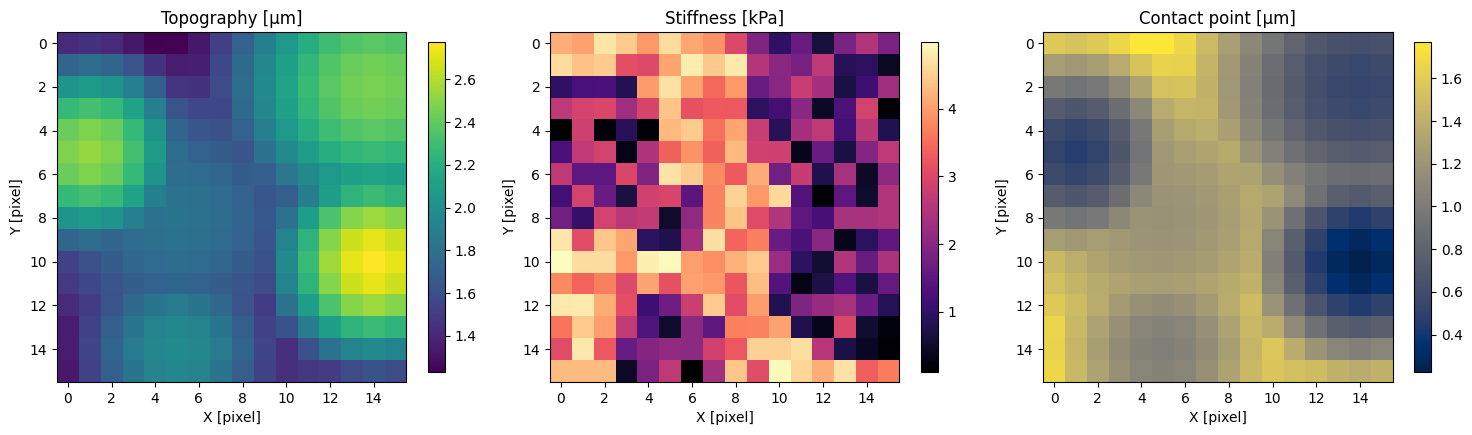

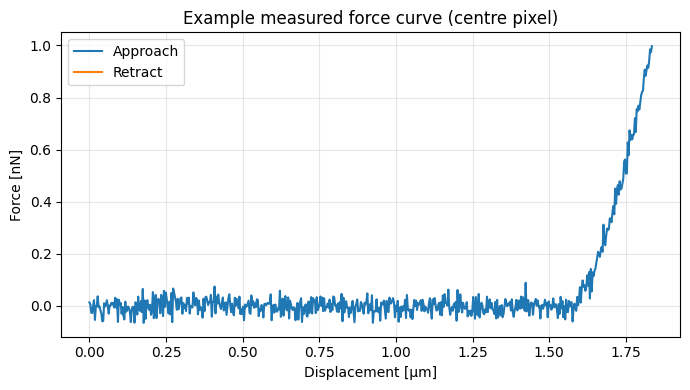

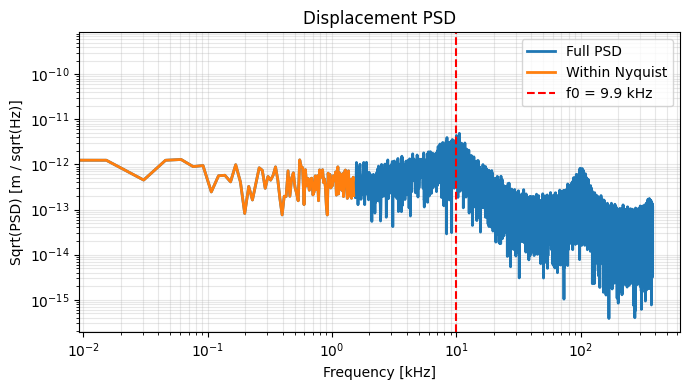

In [10]:
# We use the simulator to generate data and visualise it with the functions
# defined above.
rng = np.random.default_rng(SEED)

example_substrate_stiffness_range_pa = (3e3, 5e3)
example_feature_stiffness_range_pa = (0.1e3, 3e3)
example_nx = 16
example_ny = 16

example_stiffness_min_pa = min(example_substrate_stiffness_range_pa[0],
                               example_feature_stiffness_range_pa[0])
example_stiffness_max_pa = max(example_substrate_stiffness_range_pa[1],
                               example_feature_stiffness_range_pa[1])

cantilever = AFMCantilever(k=0.178, f0=10e3, Q=100.0, T=300.0)
contact_model = HertzContact(R=1e-6, nu=0.5, alpha=18.0)
sample_generator = SampleGenerator(
    substrate_stiffness_range_pa=example_substrate_stiffness_range_pa,
    feature_stiffness_range_pa=example_feature_stiffness_range_pa,
    height_range_m=dataset_config.height_range_m
)
simulator = AFMSimulator(
    cantilever=cantilever,
    contact_model=contact_model,
    sample_generator=sample_generator,
    config=simulation_config,
)

print(f"Approach points = {simulator.n_points_approach}")
print(f"Setpoint force range = \
{min(simulation_config.setpoint_force_n_range) * 1e9:.2f} - \
{max(simulation_config.setpoint_force_n_range) * 1e9:.2f} nN")

example_topography_m, example_stiffness_pa = (
    sample_generator.create_topography(
        size=(example_nx, example_ny),
        pixel_size_m=simulation_config.pixel_size_m,
        topography_type="gaussian_features",
        rng=rng,
    )
)

example_output = simulator.simulate_force_map(
    stiffness_map_pa=example_stiffness_pa,
    topography_map_m=example_topography_m,
    include_thermal_noise=simulation_config.include_thermal_noise,
    rng=rng,
)

plot_maps(example_topography_m, example_stiffness_pa, example_output["contact_point_map_m"])

center_row = 0
center_col = 0
plot_force_curve(
    example_output["displacement_curves_m"][center_row, center_col],
    example_output["measured_force_curves_n"][center_row, center_col],
    retract_start_index= \
      int(example_output["retract_start_indices"][center_row, center_col]),
    valid_length=int(example_output["curve_lengths"][center_row, center_col]),
    title="Example measured force curve (centre pixel)",
)

reference_points = max(simulator.n_points_approach * 2, 64)
if simulation_config.noise_type == "rms":
    frequency_hz, spectral_density_m2_per_hz = cantilever.get_noise_psd(
        n_points=reference_points,
        sampling_frequency_hz=cantilever.f0*10,
        noise_type="theoretical",
        experimental_path=simulation_config.experimental_noise_path,
    )

else:
    frequency_hz, spectral_density_m2_per_hz = cantilever.get_noise_psd(
        n_points=reference_points,
        sampling_frequency_hz=cantilever.f0*10,
        noise_type=simulation_config.noise_type,
        experimental_path=simulation_config.experimental_noise_path,
    )
plot_psd(
    frequency_hz,
    spectral_density_m2_per_hz,
    cantilever,
    sampling_frequency=simulation_config.sampling_frequency_hz,
)


## 9. Curve Generation and Preprocessing

Generate the curves and interpolate the tip displament and measured force to fix length ...

In [11]:
align_length = 1500

rng = np.random.default_rng(577)
ny = simulator.config.ny
nx = simulator.config.nx

stiffness_range_min = \
min(simulator.sample_generator.substrate_stiffness_range_pa[0], \
    simulator.sample_generator.feature_stiffness_range_pa[0])
stiffness_range_max = \
max(simulator.sample_generator.substrate_stiffness_range_pa[1], \
    simulator.sample_generator.feature_stiffness_range_pa[1])

def preprocess_synthetic_data(
    output: dict,
    stiffness_map_pa: np.ndarray,
    align_length: int,
    stiffness_range_min: float,
    stiffness_range_max: float,
    cut_nb: int = 10,
)-> tuple[np.ndarray, np.ndarray]:
    """Preprocess synthetic AFM data for regression.

    Parameters
    ----------
    output: dict
        Output from the AFMSimulator containing force curves and metadata.
    stiffness_map_pa: np.ndarray
        Stiffness map in pascals.
    align_length: int
        Length to which all curves will be aligned (via interpolation).
    stiffness_range_min: float
        Minimum stiffness value for normalization.
    stiffness_range_max: float
        Maximum stiffness value for normalization.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Tuple of (data_x, data_y) where data_x contains the aligned force
        curves and data_y contains the corresponding contact points and
        stiffness values.

    """

    ny = output["curve_lengths"].shape[0]
    nx = output["curve_lengths"].shape[1]

    n_total = ny * nx * cut_nb
    data_x = np.empty((n_total, align_length * 2), dtype=np.float32) 
    data_y = np.empty((n_total, 2), dtype=np.float32)
    idx = 0

    for r in range(ny):
        for c in range(nx):
            disp_all = output["displacement_curves_m"][r, c]
            disp_all = np.asarray(disp_all, dtype=np.float64)

            meas_all = output["measured_force_curves_n"][r, c]
            meas_all = np.asarray(meas_all, dtype=np.float64)
            stif = float(stiffness_map_pa[r, c])
            cp_og = float(output["contact_point_map_m"][r, c])

            for j in range(cut_nb):
                cp = deepcopy(cp_og)
                stif = deepcopy(stif)

                disp = disp_all.copy()
                meas = meas_all.copy()

                cp = disp.max() - cp
                disp = disp.max() - disp
                cp = cp/disp.max()

                cut1 = int(random.random()*0.5*cp*disp.size)
                cut2 = int((1-(1-cp)*random.random()*0.9)*disp.size)

                if cut1 >= cut2 or j==0:
                    cut1 = 0
                    cut2 = disp.size

                cp = cp*disp.max()

                disp = disp[::-1][cut1:cut2]
                meas = meas[::-1][cut1:cut2]

                x_old = np.linspace(0, 1, disp.size)
                x_new = np.linspace(0, 1, align_length)

                disp = np.interp(x_new, x_old, disp)
                meas = np.interp(x_new, x_old, meas)

                cp = cp - disp.min()
                disp = disp - disp.min()
                cp = cp/disp.max()

                disp = disp[::-1]
                meas = meas[::-1]

                data_x[idx] = np.hstack([disp*1e6,meas*1e9])
                data_y[idx] = [cp, stif]
                idx += 1


    data_y[:,1] = (data_y[:,1] - stiffness_range_min)/\
     (stiffness_range_max - stiffness_range_min)

    return data_x, data_y

n_total = dataset_config.n_samples * nx * ny * 10
data_x_r = np.empty((n_total, align_length * 2), dtype=np.float32)  # float32 halves memory
data_y_r = np.empty((n_total, 2), dtype=np.float32)
idx = 0
cp_og = []
for i in range(dataset_config.n_samples):
    topography_type = rng.choice(dataset_config.topography_types)
    topo_m, stiff_pa = sample_generator.create_topography(
        size=(ny, nx),
        pixel_size_m=simulator.config.pixel_size_m,
        topography_type=topography_type,
        rng=rng,
    )
    out = simulator.simulate_force_map(
        stiffness_map_pa=stiff_pa,
        topography_map_m=topo_m,
        include_thermal_noise=simulator.config.include_thermal_noise,
        noise_type=simulator.config.noise_type,
        experimental_path=simulator.config.experimental_noise_path,
        rng=rng,
    )

    data_x_i, data_y_i = preprocess_synthetic_data(
        out,
        stiff_pa,
        align_length,
        stiffness_range_min,
        stiffness_range_max,
        cut_nb=10,
    )

    data_x_r[idx : idx + data_x_i.shape[0]] = data_x_i
    data_y_r[idx : idx + data_y_i.shape[0]] = data_y_i
    idx += data_x_i.shape[0]
    cp_og.append(out["contact_point_map_m"].ravel())

    del out, topo_m, stiff_pa


print(f"Final dataset shape: data_x={data_x_r.shape}, data_y={data_y_r.shape}") 

Final dataset shape: data_x=(102400, 3000), data_y=(102400, 2)


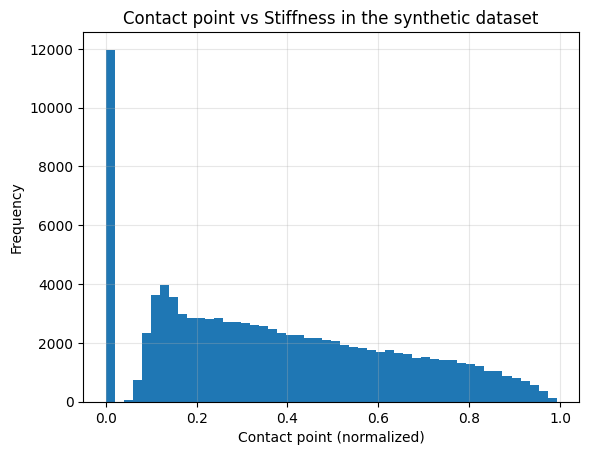

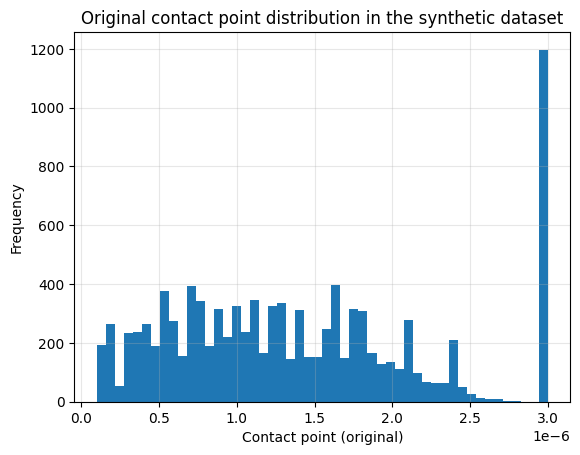

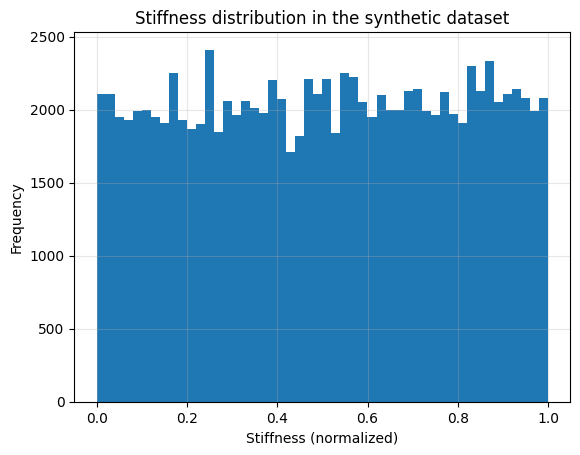

In [12]:
plt.hist(data_y_r[:,0], bins=50)
plt.xlabel("Contact point (normalized)")
plt.ylabel("Frequency")
plt.title("Contact point vs Stiffness in the synthetic dataset")
plt.grid(alpha=0.3)
plt.show()

cp_og = np.concatenate(cp_og)

plt.hist(cp_og, bins=50)
plt.xlabel("Contact point (original)")
plt.ylabel("Frequency")
plt.title("Original contact point distribution in the synthetic dataset")
plt.grid(alpha=0.3)
plt.show()

plt.hist(data_y_r[:,1], bins=50)
plt.xlabel("Stiffness (normalized)")
plt.ylabel("Frequency")
plt.title("Stiffness distribution in the synthetic dataset")
plt.grid(alpha=0.3) 
plt.show()



... and create the dataloader for tranining.

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    data_x_r, data_y_r,
    test_size=0.3,
    random_state=577
)

train_dataset = TensorDataset(
    torch.tensor(x_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)

val_dataset = TensorDataset(
    torch.tensor(x_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=model_config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=model_config.batch_size, shuffle=True)

## 10. MLP Training

We instantiate a dense layers neural network containing two heads, one for contact point estimation and one for stiffness estimation.

In [14]:
class MLP(L.LightningModule):
    """AFMCantilever regression MLP model.

    Parameters
    ----------
    lr: float
        Learning rate for the optimizer.
    
    Methods
    -------
    `forward(x) -> torch.Tensor`
        Forward pass of the MLP model.
    `training_step(batch, batch_idx) -> torch.Tensor`
        Training step for the MLP model.
    `validation_step(batch, batch_idx) -> torch.Tensor`
        Validation step for the MLP model.
    `test_step(batch, batch_idx) -> torch.Tensor`
        Test step for the MLP model.
    `configure_optimizers() -> torch.optim.Optimizer`
        Configure the optimizer for training.
    
    """
        
    def __init__(
        self: MLP, 
        lr: float = 1e-4
    ):
        """Initializes the MLP model for regression.
        
        Parameters
        ----------
        lr: float
            Learning rate for the optimizer.
        
        Returns
        -------
        None

        """
        super().__init__()
        self.save_hyperparameters()

        self.encoder = nn.Sequential(
            nn.Linear(3000, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
        )

        self.cp_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
        )

        self.sf_head = nn.Sequential(
            nn.Linear(513, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
        )

        self.loss_fn = nn.MSELoss()

    def forward(
        self: MLP, 
        x: torch.Tensor
    ) -> torch.Tensor:
        """Forward pass of the MLP model.

        Parameters
        ----------
        x: torch.Tensor
            Input tensor containing the aligned force curves, shape (batch_size, 3000).
            
        Returns
        -------
        torch.Tensor
            Output tensor containing the predicted contact points and stiffness values, shape (batch_size, 2).

        """

        feat = self.encoder(x)
        cp = self.cp_head(feat)

        stiffness_input = torch.cat([feat, cp], dim=1)
        stiffness = self.sf_head(stiffness_input)

        # Final output: [cp, stiffness]
        y = torch.cat([cp, stiffness], dim=1)
        return y
        
    def training_step(
        self: MLP, 
        batch: tuple[torch.Tensor, torch.Tensor],
        batch_idx: int
    ) -> torch.Tensor:
        """Training step for the MLP model.

        Parameters
        ----------
        batch: tuple[torch.Tensor, torch.Tensor]
            A tuple containing the input tensor and the target tensor.
        batch_idx: int
            Index of the batch.

        Returns
        -------
        torch.Tensor
            The computed loss for the batch.
            
        """

        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(
        self: MLP, 
        batch: tuple[torch.Tensor, torch.Tensor],
        batch_idx: int
    ) -> torch.Tensor:
        """Validation step for the MLP model.

        Parameters
        ----------
        batch: tuple[torch.Tensor, torch.Tensor]
            A tuple containing the input tensor and the target tensor.
        batch_idx: int
            Index of the batch.

        Returns
        -------
        torch.Tensor
            The computed loss for the batch.
        """

        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)
        self.log("val_loss", loss, prog_bar=True)
        return loss

    def test_step(
        self: MLP, 
        batch: tuple[torch.Tensor, torch.Tensor],
        batch_idx: int
    ) -> torch.Tensor:
        """Test step for the MLP model.

        Parameters
        ----------
        batch: tuple[torch.Tensor, torch.Tensor]
            A tuple containing the input tensor and the target tensor.
        batch_idx: int
            Index of the batch.

        Returns
        -------
        torch.Tensor
            The computed loss for the batch.
        """
        
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)
        self.log("test_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

regressor = MLP()

print(regressor)

MLP(
  (encoder): Sequential(
    (0): Linear(in_features=3000, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
  )
  (cp_head): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=1, bias=True)
  )
  (sf_head): Sequential(
    (0): Linear(in_features=513, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=1, bias=True)
  )
  (loss_fn): MSELoss()
)


We define `RunSaver` utility class that organises each experiment into a `runs/<run_name>/` directory, persisting the configuration, per-epoch metrics, model checkpoints, and final test results as JSON files. Also provides `build_run_config`, which flattens `SimulationConfig`, `DatasetConfig`, and `ModelConfig` into a single JSON-serialisable dictionary for logging.

In [15]:
class RunSaver:
    """
    Creates runs/<run_name>/ and saves:
      config.json        — all hyperparameters + ablation flags + data conditions
      metrics.json       — per-epoch train/val loss (parsed from Lightning CSV log)
      model_best.pth     — best-val-loss model weights
      model_final.pth    — last-epoch model weights
      results.json       — test metrics → feeds the ablation table
      logs/training.log  — human-readable log
    """

    def __init__(
        self: RunSaver, 
        run_name: str, 
        config: dict, 
        model_structure: str = "MLP",
        base_dir: str = "runs",
    ):
        """Initializes the RunSaver for managing experiment runs.

        Parameters
        ----------
        run_name: str
            Name of the run.
        config: dict
            Configuration dictionary containing hyperparameters and other settings.
        model_structure: str, optional
            Description of the model structure, by default "MLP".
        base_dir: str, optional
            Base directory for saving runs, by default "runs".

        Returns
        -------
        None    

        """

        self.run_name        = run_name
        self.config          = config
        self.model_structure = model_structure
        self.run_dir         = Path(base_dir) / run_name
        self.run_dir.mkdir(parents=True, exist_ok=True)

        self.best_val_loss = float("inf")
        self.best_epoch    = 0

        self._init_logger()
        self._save_json(config, "config.json")
        self.logger.info(f"Run: {run_name}")

    def _init_logger(
        self
    ):
        """Initializes the logger for the run.

        Creates a logger that writes to both a file and the console, with timestamps.
        
        Returns
        -------
        None

        """
    
        log_dir = self.run_dir / "logs"
        log_dir.mkdir(exist_ok=True)
        logger = logging.getLogger(self.run_name)
        logger.setLevel(logging.INFO)
        if not logger.handlers:
            fh = logging.FileHandler(log_dir / "training.log")
            sh = logging.StreamHandler()
            fmt = logging.Formatter("%(asctime)s  %(message)s", "%H:%M:%S")
            fh.setFormatter(fmt)
            sh.setFormatter(fmt)
            logger.addHandler(fh)
            logger.addHandler(sh)
        self.logger = logger

    def _save_json(
        self: RunSaver, 
        data: dict, 
        filename: str
    ):
        """Saves a dictionary as a JSON file in the run directory.

        Parameters
        ----------
        data: dict
            The dictionary to save.
        filename: str
            The name of the JSON file.

        Returns
        -------
        None

        """

        def _convert(obj):
            if isinstance(obj, np.integer):  return int(obj)
            if isinstance(obj, np.floating): return float(obj)
            if isinstance(obj, np.ndarray):  return obj.tolist()
            if isinstance(obj, tuple):       return list(obj)
            return obj
        with open(self.run_dir / filename, "w") as f:
            json.dump(
                {k: _convert(v) for k, v in data.items()}
                if isinstance(data, dict) else data,
                f, indent=2,
            )

    def load_history_from_csv(
        self: RunSaver, 
        csv_path: str
    ) -> dict:
        """Parse a Lightning CSVLogger metrics.csv into a history dict.

        Parameters
        ----------
        csv_path: str
            Path to the metrics.csv file generated by Lightning's CSVLogger.

        Returns
        -------
        dict
            A dictionary with 'train_loss' and 'val_loss' lists, one entry per epoch.

        """

        metrics  = pd.read_csv(csv_path)
        train_df = (
            metrics[metrics["train_loss"].notna()]
            .groupby("epoch", as_index=False)["train_loss"]
            .mean()
        )
        val_df = metrics[metrics["val_loss"].notna()][["epoch", "val_loss"]]
        return {
            "train_loss": train_df["train_loss"].tolist(),
            "val_loss":   val_df["val_loss"].tolist(),
        }

    def save_history(
        self: RunSaver,
        history: dict
    ):
        """Persist metrics.json and log an epoch-by-epoch summary.

        Parameters
        ----------
        history: dict
            Dict with 'train_loss' and 'val_loss' lists (one entry per epoch).

        Returns
        -------
        None

        """

        self._save_json(history, "metrics.json")
        val_losses = history.get("val_loss", [])
        if val_losses:
            self.best_epoch    = int(np.argmin(val_losses)) + 1
            self.best_val_loss = float(np.min(val_losses))
        n_epochs = len(history.get("val_loss", []))
        for i in range(n_epochs):
            tl = history["train_loss"][i] if history.get("train_loss") else None
            vl = val_losses[i] if val_losses else None
            self.logger.info(
                f"Ep {i+1:04d} | train_loss={tl:.6f}  val_loss={vl:.6f}"
            )

    def save_checkpoint(
        self: RunSaver,
        model: nn.Module, 
        tag: str,
    ):
        """Save model state dict to model_<tag>.pth.

        Parameters
        ----------
        model: nn.Module
            The model to save.
        tag: str
            File suffix, e.g. 'best' or 'final'.

        Returns
        -------
        None

        """

        torch.save(model.state_dict(), self.run_dir / f"model_{tag}.pth")
        self.logger.info(f"  Checkpoint saved: model_{tag}.pth")

    def save_results(
        self: RunSaver,
        test_mse_cp: float,
        test_rmse_cp: float,
        test_mse_stiffness: float,
        test_rmse_stiffness: float,
        num_params: int,
    ) -> dict:
        """Build results.json and return the dict for in-notebook use.

        Parameters
        ----------
        test_mse_cp: float
            Test MSE for contact-point prediction (µm²).
        test_rmse_cp: float
            Test RMSE for contact-point prediction (µm).
        test_mse_stiffness: float
            Test MSE for stiffness prediction (kPa²).
        test_rmse_stiffness: float
            Test RMSE for stiffness prediction (kPa).
        num_params: int
            Total number of trainable model parameters.

        Returns
        -------
        dict
            The results dictionary written to results.json.

        """

        results = {
            # identifier
            "run_name":              self.run_name,
            # model / training (ablation axes)
            "learning_rate":         self.config.get("learning_rate"),
            "batch_size":            self.config.get("batch_size"),
            "max_epochs":            self.config.get("max_epochs"),
            "predict_contact_point": self.config.get("predict_contact_point"),
            # simulation conditions (ablation axes)
            "tip_shape":             self.config.get("tip_shape"),
            "include_thermal_noise": self.config.get("include_thermal_noise"),
            "noise_type":            self.config.get("noise_type"),
            "curve_mode":            self.config.get("curve_mode"),
            "artefact":              self.config.get("artefact"),
            # data conditions
            "n_samples":             self.config.get("n_samples"),
            "topography_types":      self.config.get("topography_types"),
            # performance
            "test_mse_cp":           round(test_mse_cp,          6),
            "test_rmse_cp":          round(test_rmse_cp,         6),
            "test_mse_stiffness":    round(test_mse_stiffness,   6),
            "test_rmse_stiffness":   round(test_rmse_stiffness,  6),
            "best_val_loss":         round(self.best_val_loss,    6),
            "best_epoch":            self.best_epoch,
            "num_params":            num_params,
            # reproducibility
            "seed":                  self.config.get("seed"),
            "timestamp":             datetime.now().isoformat(),
        }
        self._save_json(results, "results.json")
        self.logger.info(
            f"Results saved — "
            f"test_rmse_cp={test_rmse_cp:.6f}  "
            f"test_rmse_stiffness={test_rmse_stiffness:.6f}"
        )
        return results


def build_run_config(
    sim_cfg: SimulationConfig,
    data_cfg: DatasetConfig,
    model_cfg: ModelConfig,
    seed: int = SEED,
) -> dict:
    """Flatten the three config dataclasses into one JSON-serialisable dict.
    
    Parameters
    ----------
    sim_cfg: SimulationConfig
        Simulation configuration dataclass.
    data_cfg: DatasetConfig
        Dataset configuration dataclass.
    model_cfg: ModelConfig
        Model configuration dataclass.
    seed: int, optional
        Random seed for reproducibility, by default SEED.

    Returns
    -------
    dict
        Flattened configuration dictionary.

    """
    
    return {
        # SimulationConfig — ablation axes
        "tip_shape":                     sim_cfg.tip_shape,
        "include_thermal_noise":         sim_cfg.include_thermal_noise,
        "noise_type":                    sim_cfg.noise_type,
        "curve_mode":                    sim_cfg.curve_mode,
        "artefact":                      sim_cfg.artefact,
        # SimulationConfig — experimental conditions
        "z_length_m":                    sim_cfg.z_length_m,
        "z_speed_um_s":                  sim_cfg.z_speed_um_s,
        "sampling_frequency_hz":         sim_cfg.sampling_frequency_hz,
        "setpoint_force_n_range":        list(sim_cfg.setpoint_force_n_range),
        # DatasetConfig
        "n_samples":                     data_cfg.n_samples,
        "topography_types":              list(data_cfg.topography_types),
        "substrate_stiffness_range_pa":  list(data_cfg.substrate_stiffness_range_pa),
        "feature_stiffness_range_pa":    list(data_cfg.feature_stiffness_range_pa),
        "height_range_m":                list(data_cfg.height_range_m),
        # ModelConfig
        "batch_size":                    model_cfg.batch_size,
        "learning_rate":                 model_cfg.learning_rate,
        "max_epochs":                    model_cfg.max_epochs,
        "predict_contact_point":         model_cfg.predict_contact_point,
        "cp_loss_weight":                model_cfg.cp_loss_weight,
        # Reproducibility
        "seed":                          seed,
    }


... compile it ...

In [16]:
# Save the top-1 model according to the validation loss
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=3,
)

# Stop training if val_loss doesn't improve for 20 epochs
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    patience=40,
    mode="min",
    verbose=True,
)

# Set the logger
csv_logger = CSVLogger("logs", name="regressor")

# Instantiate the trainer
trainer = dl.Trainer(
    max_epochs=1000,
    accelerator="auto",
    callbacks=[checkpoint_callback, early_stop_callback],
    logger=csv_logger,
    log_every_n_steps=5,
    enable_progress_bar=True,
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


... and print the summary of the compiled model.

In [17]:
trainer.fit(regressor, train_loader, val_loader)

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ Sequential │  3.6 M │ train │     0 │
│ 1 │ cp_head │ Sequential │  131 K │ train │     0 │
│ 2 │ sf_head │ Sequential │  131 K │ train │     0 │
│ 3 │ loss_fn │ MSELoss    │      0 │ train │     0 │
└───┴─────────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.9 M                                                                                                
Total estimated model params size (MB): 15                                                                         
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:485: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors

Training: |          | 0/? [00:00<?, ?it/s]

...

Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.006


Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


We read the Lightning `CSVLogger` metrics CSV file, groups train loss per epoch, and plots training and validation loss curves side by side to visualise model convergence.

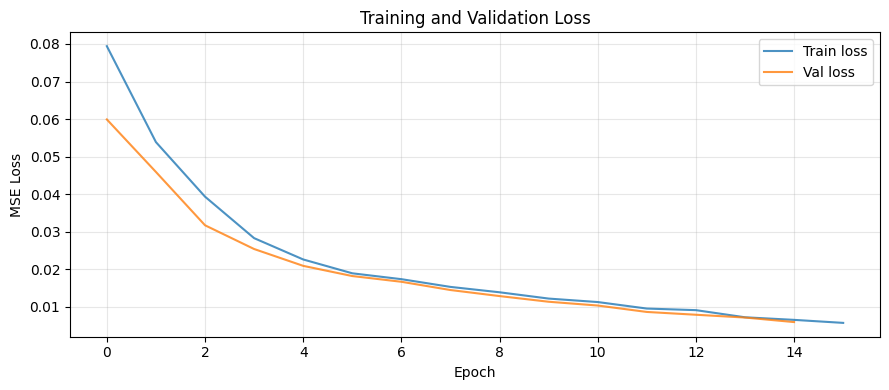

Loaded from: logs/regressor/version_7/metrics.csv


In [18]:
# Find the latest version log directory
metrics_path = str(Path(csv_logger.log_dir) / "metrics.csv")

if Path(metrics_path).exists():
    metrics = pd.read_csv(metrics_path)

    # val_loss is logged once per epoch; train_loss is logged every N steps
    # — average train_loss per epoch so both share the same x-axis
    train_metrics = (
        metrics[metrics["train_loss"].notna()]
        .groupby("epoch", as_index=False)["train_loss"]
        .mean()
    )
    val_metrics = metrics[metrics["val_loss"].notna()][["epoch", "val_loss"]]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(
        train_metrics["epoch"],
        train_metrics["train_loss"],
        label="Train loss",
        alpha=0.8
        )
    ax.plot(
        val_metrics["epoch"],
        val_metrics["val_loss"],
        label="Val loss",
        alpha=0.8
        )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_title("Training and Validation Loss")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Loaded from: {metrics_path}")
else:
    print("No metrics.csv found. Run training first.")


## 11. Evaluate on the Generated Map

Load the best model from the callback function.

In [19]:
LOAD_PRETRAINED_MODEL = False

if LOAD_PRETRAINED_MODEL:
    pretraiend_model_path = "logs/regressor/version_15/checkpoints/epoch=349-step=6300.ckpt"

    print(f"Loading the model at {pretraiend_model_path}")

    best_regressor = MLP.load_from_checkpoint(
        pretraiend_model_path
    )

else: 
    print(f"The best model is saved at {checkpoint_callback.best_model_path}")

    best_regressor = MLP.load_from_checkpoint(
        checkpoint_callback.best_model_path
    )

The best model is saved at logs/regressor/version_7/checkpoints/epoch=14-step=270.ckpt


Plot the map-level example again ...

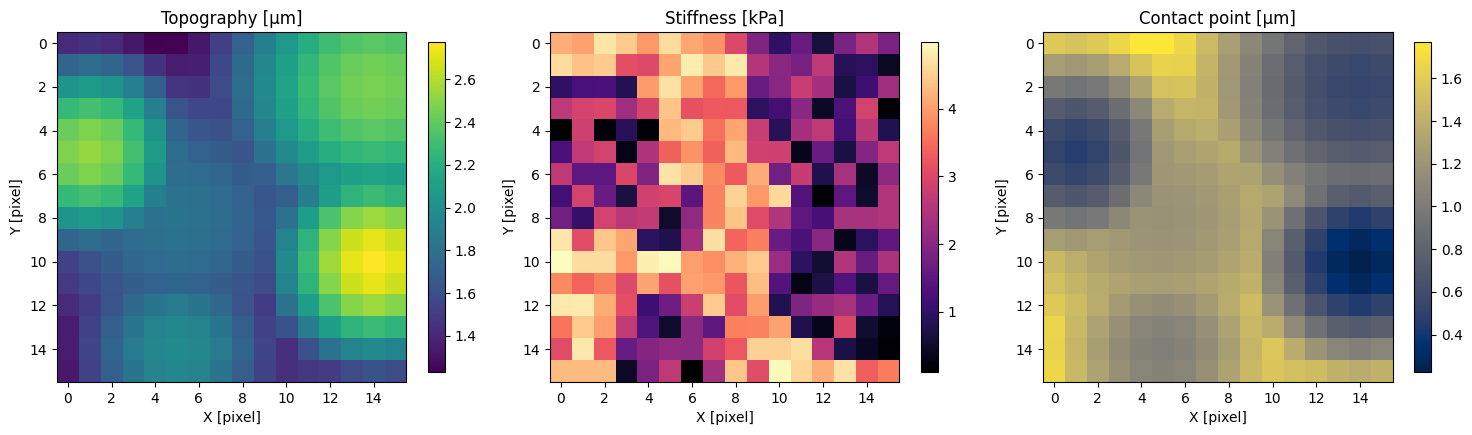

In [20]:
plot_maps(example_topography_m, example_stiffness_pa, example_output["contact_point_map_m"])

... process them for model inference and predict the contact points and stiffness ...

In [21]:
data_input, data_target = preprocess_synthetic_data(
    example_output,
    example_stiffness_pa,
    align_length,
    example_stiffness_min_pa,
    example_stiffness_max_pa,
    cut_nb=1,
)

test_dataset = TensorDataset(
    torch.tensor(data_input, dtype=torch.float32),
    torch.tensor(data_target, dtype=torch.float32)
)

test_loader = DataLoader(test_dataset, batch_size=nx*ny, shuffle=False)

Calculate the metrics in generated map ...

In [22]:
_ = trainer.test(best_regressor, test_loader)

/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.005459877196699381    │
└───────────────────────────┴───────────────────────────┘

We define `pass_through_model` function, which runs a full batched forward pass, collects raw inputs, ground-truth targets, and predictions, then denormalises both outputs back to physical units (µm for contact point, Pa for stiffness). Than we apply the fucntion to the simulated example map.

In [23]:
device = next(best_regressor.parameters()).device

def pass_through_model(
    model: MLP,
    dataloader: DataLoader,
    device: torch.device,
    stiffness_range_min: float,
    stiffness_range_max: float
)-> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Pass data through the model and collect predictions.

    Parameters
    ----------
    model: MLP
        Trained MLP model for regression.
    dataloader: DataLoader
        DataLoader containing the test dataset.
    device: torch.device
        Device on which the model is located (CPU or GPU).
    stiffness_range_min: float
        Minimum stiffness value used for normalization (for denormalizing).
    stiffness_range_max: float
        Maximum stiffness value used for normalization (for denormalizing).

    Returns
    -------
    tuple[np.ndarray, np.ndarray, np.ndarray]
        Tuple of (all_x, all_y, all_y_hat) where all_x contains the input data,
        all_y contains the true targets, and all_y_hat contains the model
        predictions.

    """

    all_y = []
    all_y_hat = []
    all_x = []
    with torch.no_grad():
        for batch in dataloader:
            x, y = batch
            x = x.to(device)
            y = y.to(device)

            y_hat = model(x)
            all_x.append(x)
            all_y.append(y)
            all_y_hat.append(y_hat)

    all_x = torch.cat(all_x, dim=0)
    all_y = torch.cat(all_y, dim=0)
    all_y_hat = torch.cat(all_y_hat, dim=0)

    all_x = all_x.cpu().numpy()
    all_y = all_y.cpu().numpy()
    all_y_hat = all_y_hat.cpu().numpy()

    all_y_hat[:,1] = all_y_hat[:,1]*\
     (stiffness_range_max - stiffness_range_min) + stiffness_range_min
    all_y_hat[:,0] = all_y_hat[:,0]*all_x[:,0:1500].max(axis=1)
    all_y[:,0] = all_y[:,0]*all_x[:,0:1500].max(axis=1)
    all_y[:,1] = all_y[:,1]*\
     (stiffness_range_max - stiffness_range_min) + stiffness_range_min

    return all_x, all_y, all_y_hat

all_x_example, all_y_example, all_y_hat_example = pass_through_model(
    best_regressor,
    test_loader,
    device,
    example_stiffness_min_pa,
    example_stiffness_max_pa
)

We plot parity scatter plots comparing the true vs predicted contact point (left) and stiffness (right) on the simulated example map, with a dashed diagonal as the perfect-prediction reference.

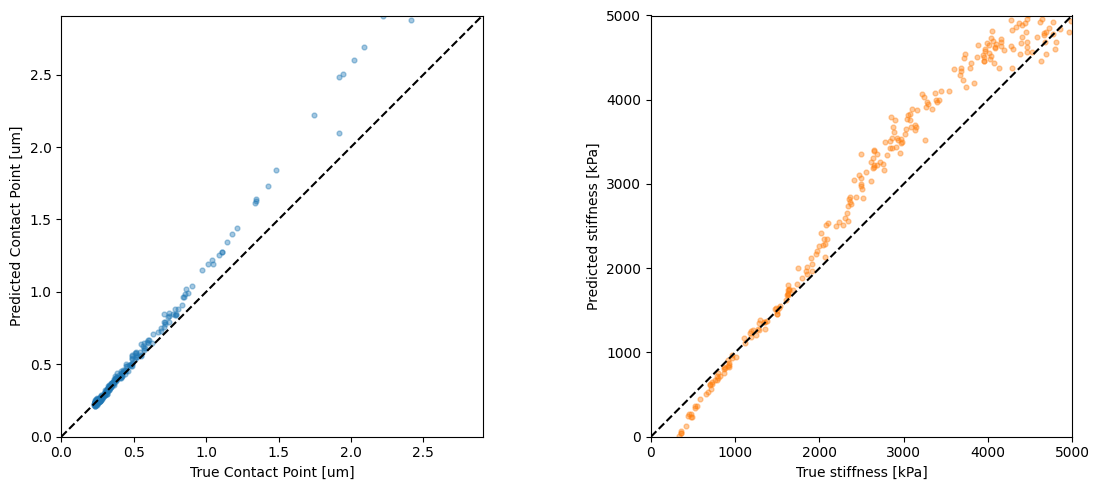

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(all_y_example[:,0],
                all_y_hat_example[:,0],
                alpha=0.4,
                s=12)
lim = [0, max(all_y_hat_example[:,0].max(), all_y_example[:,0].max())]
axes[0].plot(lim, lim, "k--", lw=1.5, label="Perfect")
axes[0].set_xlim(lim)
axes[0].set_ylim(lim)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("True Contact Point [um]")
axes[0].set_ylabel("Predicted Contact Point [um]")

axes[1].scatter(all_y_example[:,1],
                all_y_hat_example[:,1],
                alpha=0.4,
                s=12,
                color="tab:orange",)
lim = [0,5000]
axes[1].plot(lim, lim, "k--", lw=1.5, label="Perfect")
axes[1].set_xlim(lim)
axes[1].set_ylim(lim)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlabel("True stiffness [kPa]")
axes[1].set_ylabel("Predicted stiffness [kPa]")

plt.tight_layout()
plt.show()

Clickable stiffnes map-viewer to visualize the output.

In [25]:
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    output = None

try:
    import anywidget
    import ipywidgets as widgets
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
    print("Plotly FigureWidget is available.")
except Exception as error:
    widgets = None
    go = None
    PLOTLY_AVAILABLE = False
    print("Interactive Plotly viewer is unavailable in this environment.")
    print("Install these packages locally and restart the kernel:")
    print("pip install plotly anywidget ipywidgets")
    print(f"Import error: {error}")

sys.path.append(os.path.abspath("../scripts"))
import plotting
plotting = importlib.reload(plotting)

predicted_stiffness_map_pa = np.zeros_like(example_stiffness_pa)
predicted_contact_point_map_m = np.zeros_like(example_stiffness_pa)
approach_force = np.empty((example_nx, example_ny), dtype=object)
approach_force_gt = np.empty((example_nx, example_ny), dtype=object)


for r in range(example_nx):
    for c in range(example_ny):
        idx = r * example_ny + c
        cp = all_y_hat_example[idx, 0]
        stiffness = all_y_hat_example[idx, 1]
        disp = example_output["displacement_curves_m"][r, c]
        cp = cp/1e6
        cp = disp.max() - cp
        indent = np.maximum(disp - cp, 0.0)

        approach_force[r, c] = contact_model.force(
            cantilever_shape=simulation_config.tip_shape,
            indentation_m=indent,
            stiffness_pa=stiffness,
        )
        
        del indent
        predicted_contact_point_map_m[r, c] = cp
        predicted_stiffness_map_pa[r, c] = stiffness


plotting.display_clickable_stiffness_map(
    test_collection=example_output,
    example_stiffness_map_pa = example_stiffness_pa,
    predicted_stiffness_map_pa=predicted_stiffness_map_pa,
    approach_force=approach_force,
    predicted_contact_point_map_m=predicted_contact_point_map_m,
    contact_model=HertzContact,
    simulation_config=SimulationConfig,
    abstract_figure=True,
    save_dir='results/fitting_examples'
    )

Interactive Plotly viewer is unavailable in this environment.
Install these packages locally and restart the kernel:
pip install plotly anywidget ipywidgets
Import error: No module named 'anywidget'
Interactive Plotly viewer is unavailable in this environment.
Install these packages locally and restart the kernel:
pip install plotly anywidget ipywidgets
Import error: No module named 'anywidget'
Interactive Plotly viewer is unavailable in this environment.
Install these packages locally and restart the kernel:
pip install plotly anywidget ipywidgets
Import error: No module named 'anywidget'
Interactive viewer not available. Using static fallback.


TypeError: show_curve_for_pixel() takes 3 positional arguments but 4 were given

## 12. Evaluate on the Real Data

Download and load the 3T3 dataset. Preprocess the data to prepare for the model. Pass the dataset through the model to obtain the predictions.

In [ ]:
cut_percentage = 0

if not os.path.exists("3t3_cell_dataset"):
    os.system("git clone https://github.com/DeepTrackAI/3t3_cell_dataset")


# Load the approach curves
approach_path = Path.cwd() / "3t3_cell_dataset" / "approach"
approach_files = sorted(approach_path.glob("*.npy"), key=lambda f: int(f.stem))
approach_curves = [np.load(f) for f in approach_files]

# Load the retraction curves
retract_path = Path.cwd() / "3t3_cell_dataset" / "retraction"
retract_files = sorted(retract_path.glob("*.npy"), key=lambda f: int(f.stem))
retract_curves = [np.load(f) for f in retract_files]

# Load the labels
label_file = Path.cwd() / "3t3_cell_dataset" / "label.npy"
labels = np.load(label_file)

# Load the contact points (µm) and young modulus (Pa)
contactpoint_file = Path.cwd() / "3t3_cell_dataset" / "contact_point.npy"
contactpoints = np.load(contactpoint_file)          # µm

young_modulus_file = Path.cwd() / "3t3_cell_dataset" / "young_modulus.npy"
young_modulus = np.load(young_modulus_file)          # Pa

# Calculate the length of each curve
approach_curve_lengths = [curve.shape[0] for curve in approach_curves]
retract_curve_lengths  = [curve.shape[0] for curve in retract_curves]
min_approach_curve_length = min(approach_curve_lengths)
min_retract_curve_length  = min(retract_curve_lengths)

print(
    f"Minimum approach curve length = {min_approach_curve_length}\n"
    f"Minimum retraction curve length = {min_retract_curve_length}\n"
)

def resample_to_same_length(
    data_list: list[np.ndarray],
    target_len: int
) -> list[np.ndarray]:
    """Resample a list of 1D arrays to the same length using linear
    interpolation.

    Parameters
    ----------
    data_list: list[np.ndarray]
        List of 1D arrays to be resampled.
    target_len: int
        Target length for the resampled arrays.

    Returns
    -------
    list[np.ndarray]
        List of resampled 1D arrays.

    """

    resampled = []
    for data in data_list:
        data = np.asarray(data)
        x_old = np.linspace(0, 1, len(data))
        x_new = np.linspace(0, 1, target_len)
        resampled.append(np.interp(x_new, x_old, data))
    return resampled

data_exp_x1 = []
data_exp_x2 = []
contactpoints_exp = []

for i in approach_curves:
    contactpoints_exp.append(-i[:, 0].min())  # contact point (µm)
    disp = i[:, 0] - i[:, 0].min()  # displacement (µm), decreasing
    force = i[:, 1]                   # force (nN)
    disp = disp[0::]
    force = force[0::]
    data_exp_x1.append(disp)   # displacement (µm), decreasing
    data_exp_x2.append(force)   # force (nN)

teste1 = np.array(resample_to_same_length(data_exp_x1, align_length))
teste2 = np.array(resample_to_same_length(data_exp_x2, align_length))

denom = teste1.max(axis=1)
denom = np.where(denom == 0, np.nan, denom)  # avoid division by zero; flag degenerate curves
contactpoints_exp = np.array(contactpoints_exp) / denom
data_xe_r = np.hstack([teste1, teste2])
data_ye_r = np.vstack([contactpoints_exp, young_modulus]).T
data_ye_r[:,1] = (data_ye_r[:,1] - stiffness_range_min)/\
 (stiffness_range_max - stiffness_range_min)

real_dataset = TensorDataset(
    torch.tensor(data_xe_r, dtype=torch.float32),
    torch.tensor(data_ye_r, dtype=torch.float32)
)

exp_loader = DataLoader(real_dataset, batch_size=data_xe_r.shape[0])

all_x_exp, all_y_exp, all_y_hat_exp = pass_through_model(
    best_regressor,
    exp_loader,
    device,
    stiffness_range_min,
    stiffness_range_max
)

cut_percentages = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for iii in range(len(cut_percentages)):

    cut_percentage = cut_percentages[iii]

    data_exp_x1 = []
    data_exp_x2 = []
    contactpoints_exp_cut = []

    for ii in range(len(approach_curves)):
        i = approach_curves[ii]
        contactpoints_exp_cut.append(-i[:, 0].min())  # contact point (µm)
        disp = i[:, 0] - i[:, 0].min()  # displacement (µm), decreasing
        force = i[:, 1]   # force (nN)

        disp_range = disp.max()  # = i[:, 0].max() - i[:, 0].min()

        if all_y_hat_exp[ii, 0] < 0:
            disp = disp[int(i.shape[0]*cut_percentage)::]
            data_exp_x1.append(disp)
            force = force[int(i.shape[0]*cut_percentage)::]
            data_exp_x2.append(force)
        else:
            # all_y_hat_exp[:,0] is denormalized (µm); normalize back to [0,1]
            # by dividing by the curve's displacement range before using as a
            # fraction in the cut index, to avoid negative slice indices that
            # wrap to the end of the array and produce all-zero sub-arrays.
            if disp_range > 0:
                cp_frac = float(np.clip(all_y_hat_exp[ii, 0] / disp_range, 0.0, 1.0))
            else:
                cp_frac = 0.0
            cut_start = int(i.shape[0] * (1 - cp_frac) * cut_percentage)
            disp = disp[cut_start::]
            force = force[cut_start::]
            data_exp_x1.append(disp)
            data_exp_x2.append(force)
    
    teste1 = resample_to_same_length(data_exp_x1, 1500)
    teste2 = resample_to_same_length(data_exp_x2, 1500)

    teste1 = np.array(teste1)
    teste2 = np.array(teste2)
    contactpoints_exp_cut = np.array(contactpoints_exp_cut)

    denom = teste1.max(axis=1)
    denom = np.where(denom == 0, np.nan, denom)  # avoid division by zero
    contactpoints_exp_cut = contactpoints_exp_cut - teste1.min(axis=1)  # ensure contact point is relative to curve start
    contactpoints_exp_cut = contactpoints_exp_cut / denom
    teste1 = teste1 - teste1.min(axis=1).reshape(-1,1)
    data_xe_r = np.hstack([teste1, teste2])
    data_ye_r = np.vstack([contactpoints_exp_cut, young_modulus]).T
    data_ye_r[:,1] = (data_ye_r[:,1] - stiffness_range_min)/\
     (stiffness_range_max - stiffness_range_min)

    if iii == 0:
        data_xe_r_list = data_xe_r.copy()
        data_ye_r_list = data_ye_r.copy()
    else:
        data_xe_r_list = np.vstack([data_xe_r_list, data_xe_r.copy()])
        data_ye_r_list = np.vstack([data_ye_r_list, data_ye_r.copy()])

real_dataset_cut = TensorDataset(
    torch.tensor(data_xe_r_list, dtype=torch.float32),
    torch.tensor(data_ye_r_list, dtype=torch.float32)
)

exp_loader_cut = DataLoader(
    real_dataset_cut,
    batch_size=data_xe_r_list.shape[0]
    )

all_x_exp_cut, all_y_exp_cut, all_y_hat_exp_cut = pass_through_model(
    best_regressor,
    exp_loader_cut,
    device,
    stiffness_range_min,
    stiffness_range_max
)

all_y_exp_cut = all_y_exp_cut.reshape([len(cut_percentages), \
                                       data_xe_r.shape[0], 2]).transpose(1,0,2)
all_y_hat_exp_cut = all_y_hat_exp_cut.reshape([len(cut_percentages), \
                                       data_xe_r.shape[0], 2]).transpose(1,0,2)

all_y_exp_cut = all_y_exp_cut.mean(axis=1)
all_y_hat_exp_cut = all_y_hat_exp_cut.mean(axis=1)

Minimum approach curve length = 1557
Minimum retraction curve length = 3000



We plot a parity scatter of contact points obtained from mean-square-error fitting vs model predictions for the experimental 3T3 curves.

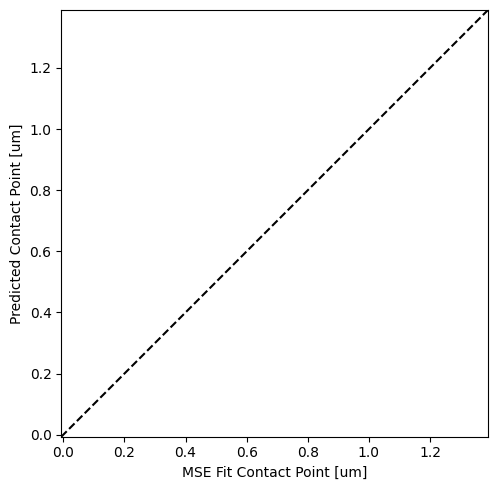

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.scatter(all_y_exp_cut[:,0][labels==1], all_y_hat_exp_cut[:,0][labels==1], 
                alpha=0.4, 
                s=12)
lim = [all_y_hat_exp_cut[:,0][labels==1].min(),
       all_y_hat_exp_cut[:,0][labels==1].max()]
ax.plot(lim, lim, "k--", lw=1.5, label="Perfect")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("MSE Fit Contact Point [um]")
ax.set_ylabel("Predicted Contact Point [um]")

plt.tight_layout()
plt.show()

We plot a parity scatter of stiffness obtained from mean-square-error fitting vs model predictions for the experimental 3T3 curves.

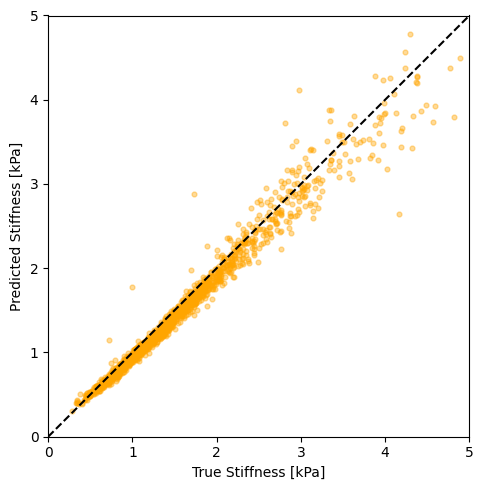

In [ ]:
pre_y = (all_y_exp_cut[:,1]/1000)[labels==1]
pre_y_hat = (all_y_hat_exp_cut[:,1]/1000)[labels==1]

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.scatter(pre_y[pre_y<5], pre_y_hat[pre_y<5],
                color="orange",
                alpha=0.4,
                s=12)
lim = [0,5]
ax.plot(lim, lim, "k--", lw=1.5, label="Perfect")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("True Stiffness [kPa]")
ax.set_ylabel("Predicted Stiffness [kPa]")

plt.tight_layout()
plt.show()

Filters the input data, MSE fit, and model predictions to the subset of class-1 curves with stiffness below 5 kPa for the subsequent reconstruction quality analysis.

In [ ]:
all_x_rec = all_x_exp_cut[:data_xe_r.shape[0]][labels==1][pre_y<5]
all_y_rec = all_y_exp_cut[labels==1][pre_y<5]
all_y_hat_rec = all_y_hat_exp_cut[labels==1][pre_y<5]

We loop over all selected curves and evaluates the Hertz contact model twice per curve; once with the ML-predicted parameters and once with the MSE fit parameters, storing the resulting force arrays for reconstruction loss comparison.

In [ ]:
approach_force_ml_list = []
approach_force_mse_list = []
approach_force_exp_list = []    

for indx in range(all_x_rec.shape[0]):
    
    approach_axis_um = all_x_rec[indx][0:1500]
    measure_force_pn = all_x_rec[indx][1500::]
    
    contact_point_um_mse = all_y_rec[indx][0]
    stiffness_pa_mse = all_y_rec[indx][1]
    
    contact_point_um_ml = all_y_hat_rec[indx][0]
    stiffness_pa_ml = all_y_hat_rec[indx][1]    

    
    approach_indent = np.maximum(
    contact_point_um_ml/1e6 - approach_axis_um/1e6, 0.0
    )
    approach_force_ml = contact_model.force(
        cantilever_shape=SimulationConfig.tip_shape,
        indentation_m=approach_indent,
        stiffness_pa=stiffness_pa_ml,
    )
    
    approach_force_ml_list.append(approach_force_ml*1e9)
    
    approach_indent = np.maximum(
    contact_point_um_mse/1e6 - approach_axis_um/1e6, 0.0
    )
    approach_force_mse = contact_model.force(
        cantilever_shape=SimulationConfig.tip_shape,
        indentation_m=approach_indent,
        stiffness_pa=stiffness_pa_mse,
    )

    approach_force_mse_list.append(approach_force_mse*1e9)
    approach_force_exp_list.append(measure_force_pn)

We stack the force lists into arrays and computes the per-curve mean-squared reconstruction error between the Hertz model output and the measured force signal, for both the ML-predicted and MSE fit parameter sets.

In [ ]:
approach_force_ml_list = np.array(approach_force_ml_list)
approach_force_mse_list = np.array(approach_force_mse_list)
approach_force_exp_list = np.array(approach_force_exp_list)
reconst_loss_ml = \
 ((approach_force_ml_list - all_x_rec[:,1500:])**2).mean(axis=1)
reconst_loss_mse = \
 ((approach_force_mse_list - all_x_rec[:,1500:])**2).mean(axis=1)

We create an interactive Plotly figure with a slider to browse all curves sorted by reconstruction loss. Each frame overlays the raw experimental signal, the ML Hertz fit (predicted parameters), and the reference Hertz fit (MSE fit parameters). Dashed vertical lines mark the ML contact point (red) and the MSE fit contact point (green).

In [ ]:
all_diff = reconst_loss_ml

# Sort by reconstruction loss
sorted_idx = np.argsort(all_diff)
y_list_sort = [approach_force_ml_list[i] for i in sorted_idx]
y_hat_list_sort = [approach_force_mse_list[i] for i in sorted_idx]
x_list_sort = [all_x_rec[i] for i in sorted_idx]
cp_ml_sort = [all_y_hat_rec[i][0] for i in sorted_idx]
cp_mse_sort = [all_y_rec[i][0] for i in sorted_idx]

diff_sort = [all_diff[i] for i in sorted_idx]

# Frames Construction
frames = []
for i in range(len(y_list_sort)):
    frames.append(
        go.Frame(
            data=[
                go.Scatter(x= x_list_sort[i][0:1500],
                           y=x_list_sort[i][1500::],
                           mode="lines",
                           name="Raw Data"
                           ),
                go.Scatter(x= x_list_sort[i][0:1500],
                           y=y_list_sort[i],
                           mode="lines",
                           name="ML"
                           ),
                go.Scatter(x= x_list_sort[i][0:1500],
                           y=y_hat_list_sort[i],
                           mode="lines",
                           name="MSE Fit"
                           ),
            ],
            name=str(i),
            layout=go.Layout(title=f"Reconstruction Loss={diff_sort[i]:.4f}",
                    shapes=[dict(type="line",x0=cp_ml_sort[i],\
                                 x1=cp_ml_sort[i],y0=0,y1=1,yref="paper",\
                                 line=dict(color="red",width=2,dash="dash")),
                            dict(type="line",x0=cp_mse_sort[i],\
                                 x1=cp_mse_sort[i],y0=0,y1=1,yref="paper",\
                                 line=dict(color="green",width=2,dash="dash"))\
                            ]),
        )
    )

# Initial Picture
fig = go.Figure(
    data=[
        go.Scatter(x= x_list_sort[0][0:1500],
                   y=x_list_sort[0][1500::],
                   mode="lines",
                   name="Raw Data"
                   ),
        go.Scatter(x= x_list_sort[0][0:1500],
                   y=y_list_sort[0],
                   mode="lines",
                   name="ML"
                   ),
        go.Scatter(x= x_list_sort[0][0:1500],
                   y=y_hat_list_sort[0],
                   mode="lines",
                   name="MSE Fit"
                   ),
    ],
    layout=go.Layout(title=f"Reconstruction Loss={diff_sort[0]:.4f}",
                    shapes=[dict(type="line",x0=cp_ml_sort[0],\
                                 x1=cp_ml_sort[0],y0=0,y1=1,yref="paper",\
                                 line=dict(color="red",width=2,dash="dash")),
                            dict(type="line",x0=cp_mse_sort[0],\
                                 x1=cp_mse_sort[0],y0=0,y1=1,yref="paper",\
                                 line=dict(color="green",width=2,dash="dash"))\
                            ]),
    frames=frames,
)

# Slider
sliders = [
    {
        "steps": [
            {
                "args": [
                    [str(i)],
                    {"frame": {"duration": 0, "redraw": True}, \
                     "mode": "immediate"},
                ],
                "label": f"{i}",
                "method": "animate",
            }
            for i in range(len(y_list_sort))
        ],
        "currentvalue": {"prefix": "Index: "},
    }
]

fig.update_layout(sliders=sliders, autosize=False, width=700, height=500)

fig.show()

AttributeError: 'NoneType' object has no attribute 'Frame'

We assemble the full run record and build a flat config dict, instantiate `RunSaver`, load training history from the Lightning CSVLogger. Then we save model checkpoints, compute contact-point and stiffness RMSE on the experimental 3T3 dataset, and save all results to `results.json`.

In [ ]:
# Build config dict and instantiate the saver
run_config = build_run_config(simulation_config, dataset_config, model_config)
run_name   = f"mlp_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
saver      = RunSaver(run_name=run_name, config=run_config, model_structure="Tanh")

# Load training history from Lightning CSV logger
metrics_csv = Path(csv_logger.log_dir) / "metrics.csv"
# metrics_path = "logs/regressor/version_12/metrics.csv"
history     = saver.load_history_from_csv(str(metrics_csv))
saver.save_history(history)

# Save model checkpoints
saver.save_checkpoint(best_regressor, "best")
saver.save_checkpoint(regressor,      "final")

# Compute test metrics on the 3T3 real dataset (label == 1)
true_cp_um     = all_y_exp_cut[:, 0][labels == 1]
pred_cp_um     = all_y_hat_exp_cut[:, 0][labels == 1]
mask_stiff     = pre_y < 5               # same <5 kPa filter used in scatter plot
true_stiff_kpa = pre_y[mask_stiff]
pred_stiff_kpa = pre_y_hat[mask_stiff]

test_mse_cp         = float(mean_squared_error(true_cp_um, pred_cp_um))
test_rmse_cp        = float(np.sqrt(test_mse_cp))
test_mse_stiffness  = float(mean_squared_error(true_stiff_kpa, pred_stiff_kpa))
test_rmse_stiffness = float(np.sqrt(test_mse_stiffness))
num_params          = sum(p.numel() for p in best_regressor.parameters())

# Save results.json
results = saver.save_results(
    test_mse_cp=test_mse_cp,
    test_rmse_cp=test_rmse_cp,
    test_mse_stiffness=test_mse_stiffness,
    test_rmse_stiffness=test_rmse_stiffness,
    num_params=num_params,
)

print(json.dumps(results, indent=2))


We scan all `runs/*/results.json` files, merge them into a single ablation DataFrame, display it inline, and save it to `runs/ablation_table.csv` for easy comparison across runs.

In [ ]:
# Aggregate all saved runs into an ablation table
run_jsons = sorted(glob.glob("runs/*/results.json"))
rows = []
for p in run_jsons:
    with open(p) as f:
        rows.append(json.load(f))

if rows:
    ablation_df = pd.DataFrame(rows)
    display(ablation_df)
    ablation_df.to_csv("runs/ablation_table.csv", index=False)
    print(f"\nAblation table ({len(rows)} run(s)) saved to runs/ablation_table.csv")
else:
    print("No runs found yet. Execute the saver cell first.")


### RMSE between experimental curves and Hertz fits

For each curve we compute the RMSE between the experimental force signal and the Hertz model evaluated at both the **MSE fit estimated** and the **predicted** parameters. Comparing the two distributions reveals whether the model's parameter estimates produce fits that are as faithful to the raw data as the MSE fit.

In [ ]:
rmse_ml = []
rmse_mse = []

for i in range(all_x_rec.shape[0]):
    rmse_ml.append(root_mean_squared_error(approach_force_exp_list[i], \
                                           approach_force_ml_list[i]))
    rmse_mse.append(root_mean_squared_error(approach_force_exp_list[i], \
                                           approach_force_mse_list[i]))

rmse_ml = np.array(rmse_ml)
rmse_mse = np.array(rmse_mse)

print(f"RMSE (mse params)  – mean: {rmse_mse.mean():.4f} nN  "
      f"median: {np.median(rmse_mse):.4f} nN")
print(f"RMSE (pred params)  – mean: {rmse_ml.mean():.4f} nN  "
      f"median: {np.median(rmse_ml):.4f} nN")
print(f"Curves where pred fit is better than truth: "
      f"{(rmse_ml < rmse_mse).sum()} / {all_x_rec.shape[0]}")

Plots overlapping RMSE histograms comparing reconstruction quality of the ML-predicted vs ground-truth Hertz fits, and a parity scatter (true RMSE vs predicted RMSE) to identify curves where the model's parameters yield a better fit than the reference.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Overlapping histograms ─────────────────────────────────────────────────
axes[0].hist(
    rmse_mse,
    bins=40,
    alpha=0.55,
    color="tab:red",
    label="True params"
    )
axes[0].hist(
    rmse_ml,
    bins=40,
    alpha=0.55,
    color="tab:blue",
    label="Pred params"
    )
axes[0].set_xlabel("RMSE [nN]", fontsize=12)
axes[0].set_ylabel("Count",     fontsize=12)
axes[0].set_title("RMSE distribution – good quality curves", fontsize=13)
axes[0].legend(fontsize=11)

# ── Scatter: RMSE_true vs RMSE_pred, diagonal = equal performance ──────────
max_lim = max(rmse_mse.max(), rmse_ml.max()) * 1.05
axes[1].scatter(rmse_mse, rmse_ml, alpha=0.35, s=14)
axes[1].plot([0, max_lim], [0, max_lim], "k--", lw=1.5, label="Equal RMSE")
axes[1].fill_between([0, max_lim], [0, 0], [0, max_lim],
                     alpha=0.06, color="tab:blue",
                     label="Pred better (below diagonal)")
axes[1].fill_between([0, max_lim], [0, max_lim], [max_lim, max_lim],
                     alpha=0.06, color="tab:red",
                     label="True better (above diagonal)")
axes[1].set_xlim(0, max_lim)
axes[1].set_ylim(0, max_lim)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlabel("RMSE – true params [nN]",      fontsize=12)
axes[1].set_ylabel("RMSE – predicted params [nN]", fontsize=12)
axes[1].set_title("True vs Predicted RMSE",        fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()